<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v3-ood/notebooks/23_ood_longform_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 23 — OOD Evaluation on Long-Form Source Text

## Research question

Does the training-horizon crossover observed on TinyStories generalize to
out-of-distribution text sampled from longer and more complex documents?

## Models

- NextLat trained with horizon 1 (H1)
- NextLat trained with horizon 8 (H8)

## Evaluation domains

- TinyStories validation: in-domain
- WikiText-103 test: out-of-distribution

## Deployment horizons

1, 2, 4, 8, 16, and 32

## Main metrics

- normalized latent L2
- decoder output KL
- teacher top-1 agreement
- H1-to-H8 crossover
- OOD degradation relative to TinyStories
- document-clustered paired bootstrap confidence intervals

This experiment evaluates 256-token chunks sampled within long-form documents.
It is not a longer-context evaluation because the model block size remains 256.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import platform
import subprocess
import torch

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory GB:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2,
        ),
    )
    print("BF16 supported:", torch.cuda.is_bf16_supported())

    result = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,memory.free",
            "--format=csv,noheader",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    print("\nnvidia-smi:")
    print(result.stdout.strip())

assert torch.cuda.is_available()
print("\nNotebook 23 environment check passed.")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
GPU memory GB: 22.03
BF16 supported: True

nvidia-smi:
NVIDIA L4, 23034 MiB, 22561 MiB

Notebook 23 environment check passed.


In [3]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)
V3_ROOT = PROJECT_ROOT / "research_v3"

print("Project root:", PROJECT_ROOT)
print("Research V3 root:", V3_ROOT)
print("Project exists:", PROJECT_ROOT.exists())
print("Research V3 exists:", V3_ROOT.exists())

assert PROJECT_ROOT.exists()
assert V3_ROOT.exists()

print("\nTop-level Research V3 directories:")

for path in sorted(V3_ROOT.iterdir()):
    print(
        "-",
        path.name,
        "directory" if path.is_dir() else "file",
    )

print("\nNotebook 23 path setup passed.")

Project root: /content/drive/MyDrive/ma2288_nextlat
Research V3 root: /content/drive/MyDrive/ma2288_nextlat/research_v3
Project exists: True
Research V3 exists: True

Top-level Research V3 directories:
- checkpoints directory
- configs directory
- data directory
- logs directory
- results directory

Notebook 23 path setup passed.


In [4]:
checkpoint_candidates = sorted(
    V3_ROOT.glob("checkpoints/**/*.pt")
)

print("=" * 100)
print("CHECKPOINT CANDIDATES")
print("=" * 100)

for index, path in enumerate(checkpoint_candidates):
    name_lower = path.name.lower()
    path_lower = str(path).lower()

    if (
        "nextlat" in path_lower
        or "h8" in path_lower
        or "5000" in name_lower
    ):
        print(
            f"[{index:03d}]",
            path,
            f"({path.stat().st_size / 1024**2:.2f} MB)",
        )

print("\nTotal .pt files:", len(checkpoint_candidates))

CHECKPOINT CANDIDATES
[000] /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/benchmark_100_gpt_seed42/GPT_Scaled_100Step_Seed42-seed42/ckpt_iter_101_3.8622.pt (40.42 MB)
[001] /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/benchmark_100_nextlat_h8_seed42/NextLat_H8_100Step_Seed42-seed42/ckpt_iter_101_5.2065.pt (50.74 MB)
[002] /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/benchmark_100_nextlat_seed42/NextLat_Scaled_100Step_Seed42-seed42/ckpt_iter_101_5.0151.pt (50.74 MB)
[003] /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_1000_1.9757.pt (40.42 MB)
[004] /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_2500_1.6914.pt (40.42 MB)
[005] /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_1.5551.pt (40.42 MB)


In [5]:
from pathlib import Path
import torch

OFFICIAL_COMMIT = (
    "3770be6009cea2b3c455a9ce7f2ca88b504bb955"
)

H1_CHECKPOINT = (
    V3_ROOT
    / "checkpoints"
    / "nextlat_pilot_5000_seed42"
    / "NextLat_Scaled_5000Step_Seed42-seed42"
    / "ckpt_iter_5000_2.0028.pt"
)

H8_CHECKPOINT = (
    V3_ROOT
    / "checkpoints"
    / "nextlat_h8_pilot_5000_seed42"
    / "NextLat_H8_5000Step_Seed42-seed42"
    / "ckpt_iter_5000_2.3431.pt"
)

H1_CONFIG_PATH = H1_CHECKPOINT.parent / "materialized_config.yaml"
H8_CONFIG_PATH = H8_CHECKPOINT.parent / "materialized_config.yaml"

print("=" * 100)
print("MATCHED CHECKPOINT SELECTION")
print("=" * 100)

for name, path in [
    ("H1 checkpoint", H1_CHECKPOINT),
    ("H8 checkpoint", H8_CHECKPOINT),
    ("H1 config", H1_CONFIG_PATH),
    ("H8 config", H8_CONFIG_PATH),
]:
    print(f"{name}:")
    print(path)
    print("Exists:", path.exists())

    if path.exists() and path.is_file():
        print(
            "Size MB:",
            round(path.stat().st_size / 1024**2, 3),
        )

    print()

assert H1_CHECKPOINT.exists()
assert H8_CHECKPOINT.exists()
assert H1_CONFIG_PATH.exists()
assert H8_CONFIG_PATH.exists()

h1_checkpoint_object = torch.load(
    H1_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

h8_checkpoint_object = torch.load(
    H8_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

print("H1 training steps:", h1_checkpoint_object["training_steps"])
print("H8 training steps:", h8_checkpoint_object["training_steps"])

print(
    "H1 state-dict tensors:",
    len(h1_checkpoint_object["model"]),
)
print(
    "H8 state-dict tensors:",
    len(h8_checkpoint_object["model"]),
)

assert h1_checkpoint_object["training_steps"] == 5000
assert h8_checkpoint_object["training_steps"] == 5000
assert set(h1_checkpoint_object["model"]) == set(
    h8_checkpoint_object["model"]
)

print("\nCell 6 matched checkpoint selection passed.")

MATCHED CHECKPOINT SELECTION
H1 checkpoint:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_2.0028.pt
Exists: True
Size MB: 50.743

H8 checkpoint:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42/NextLat_H8_5000Step_Seed42-seed42/ckpt_iter_5000_2.3431.pt
Exists: True
Size MB: 50.743

H1 config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/materialized_config.yaml
Exists: True
Size MB: 0.002

H8 config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42/NextLat_H8_5000Step_Seed42-seed42/materialized_config.yaml
Exists: True
Size MB: 0.002

H1 training steps: 5000
H8 training steps: 5000
H1 state-dict tensors: 31
H8 state-dict tensors: 31

Cell 6 matched checkpoint selection passed.


In [6]:
from pathlib import Path
import subprocess

OFFICIAL_REPO = Path("/content/NextLat")

if not (OFFICIAL_REPO / ".git").exists():
    clone_result = subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/JaydenTeoh/NextLat.git",
            str(OFFICIAL_REPO),
        ],
        capture_output=True,
        text=True,
    )

    print("Clone return code:", clone_result.returncode)

    if clone_result.stdout:
        print("\nSTDOUT:")
        print(clone_result.stdout)

    if clone_result.stderr:
        print("\nSTDERR:")
        print(clone_result.stderr[-2000:])

    assert clone_result.returncode == 0

checkout_result = subprocess.run(
    [
        "git",
        "-C",
        str(OFFICIAL_REPO),
        "checkout",
        "--detach",
        OFFICIAL_COMMIT,
    ],
    capture_output=True,
    text=True,
)

print("Checkout return code:", checkout_result.returncode)

if checkout_result.stdout:
    print(checkout_result.stdout)

if checkout_result.stderr:
    print(checkout_result.stderr[-2000:])

assert checkout_result.returncode == 0

loaded_commit = subprocess.run(
    [
        "git",
        "-C",
        str(OFFICIAL_REPO),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

print("\nOfficial repository:", OFFICIAL_REPO)
print("Required commit:", OFFICIAL_COMMIT)
print("Loaded commit:", loaded_commit)

assert loaded_commit == OFFICIAL_COMMIT

print("\nCell 7 official commit validation passed.")

Clone return code: 0

STDERR:
Cloning into '/content/NextLat'...

Checkout return code: 0
HEAD is now at 3770be6 Initial public release


Official repository: /content/NextLat
Required commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955
Loaded commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955

Cell 7 official commit validation passed.


In [7]:
import importlib
import importlib.metadata

dependency_imports = {
    "lightning": "lightning",
    "liger-kernel": "liger_kernel",
    "omegaconf": "omegaconf",
    "datasets": "datasets",
    "transformers": "transformers",
    "wandb": "wandb",
    "yaml": "yaml",
    "tqdm": "tqdm",
}

missing_packages = []

print("=" * 80)
print("DEPENDENCY CHECK")
print("=" * 80)

for package_name, import_name in dependency_imports.items():
    try:
        module = importlib.import_module(import_name)

        try:
            version = importlib.metadata.version(package_name)
        except Exception:
            version = getattr(module, "__version__", "unknown")

        print(
            f"{package_name:<20}",
            "AVAILABLE",
            version,
        )

    except Exception:
        print(f"{package_name:<20}", "MISSING")
        missing_packages.append(package_name)

print("\nMissing packages:", missing_packages)

DEPENDENCY CHECK
lightning            MISSING
liger-kernel         MISSING
omegaconf            AVAILABLE 2.3.1
datasets             AVAILABLE 4.0.0
transformers         AVAILABLE 5.13.1
wandb                AVAILABLE 0.28.0
yaml                 AVAILABLE 6.0.3
tqdm                 AVAILABLE 4.67.3

Missing packages: ['lightning', 'liger-kernel']


In [8]:
import subprocess
import sys

packages_to_install = []

if "lightning" in missing_packages:
    packages_to_install.append("lightning==2.6.5")

if "liger-kernel" in missing_packages:
    packages_to_install.append("liger-kernel==0.8.0")

if packages_to_install:
    print("Installing:", packages_to_install)

    install_result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *packages_to_install,
        ],
        capture_output=True,
        text=True,
    )

    print("Return code:", install_result.returncode)

    if install_result.stdout:
        print("\nSTDOUT:")
        print(install_result.stdout[-3000:])

    if install_result.stderr:
        print("\nSTDERR:")
        print(install_result.stderr[-3000:])

    assert install_result.returncode == 0

else:
    print("All required packages are already installed.")

print("\nCell 9 dependency installation completed.")

Installing: ['lightning==2.6.5', 'liger-kernel==0.8.0']
Return code: 0

STDOUT:
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 54.1 MB/s eta 0:00:00


Cell 9 dependency installation completed.


In [9]:
import sys
import importlib
import importlib.metadata

if str(OFFICIAL_REPO) not in sys.path:
    sys.path.insert(0, str(OFFICIAL_REPO))

print("=" * 100)
print("PACKAGE VERSIONS")
print("=" * 100)

for package_name in [
    "torch",
    "lightning",
    "liger-kernel",
    "omegaconf",
    "datasets",
    "transformers",
    "wandb",
]:
    try:
        print(
            f"{package_name:<18}",
            importlib.metadata.version(package_name),
        )
    except Exception as error:
        print(
            f"{package_name:<18}",
            "VERSION UNAVAILABLE:",
            repr(error),
        )

print("\n" + "=" * 100)
print("OFFICIAL IMPORT SMOKE TEST")
print("=" * 100)

official_modules = [
    "data.tinystories",
    "models.model_base",
    "models.model_gpt",
    "models.model_nextlat",
    "core_train",
]

for module_name in official_modules:
    importlib.import_module(module_name)
    print(f"{module_name:<32} PASS")

print("\nAll official imports passed.")

PACKAGE VERSIONS
torch              2.11.0+cu128
lightning          2.6.5
liger-kernel       0.8.0
omegaconf          2.3.1
datasets           4.0.0
transformers       5.13.1
wandb              0.28.0

OFFICIAL IMPORT SMOKE TEST
data.tinystories                 PASS
models.model_base                PASS
models.model_gpt                 PASS
models.model_nextlat             PASS
core_train                       PASS

All official imports passed.


In [10]:
import yaml


def flatten_dictionary(dictionary, prefix=""):
    flattened = {}

    for key, value in dictionary.items():
        full_key = f"{prefix}.{key}" if prefix else key

        if isinstance(value, dict):
            flattened.update(
                flatten_dictionary(
                    value,
                    prefix=full_key,
                )
            )
        else:
            flattened[full_key] = value

    return flattened


with open(
    H1_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as config_file:
    h1_runtime_config = yaml.safe_load(config_file)

with open(
    H8_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as config_file:
    h8_runtime_config = yaml.safe_load(config_file)

h1_flat_config = flatten_dictionary(
    h1_runtime_config
)
h8_flat_config = flatten_dictionary(
    h8_runtime_config
)

all_config_fields = sorted(
    set(h1_flat_config)
    | set(h8_flat_config)
)

configuration_differences = []

for field in all_config_fields:
    h1_value = h1_flat_config.get(
        field,
        "<MISSING>",
    )
    h8_value = h8_flat_config.get(
        field,
        "<MISSING>",
    )

    if h1_value != h8_value:
        configuration_differences.append(
            {
                "field": field,
                "horizon_1": h1_value,
                "horizon_8": h8_value,
            }
        )

print("=" * 120)
print("FULL H1 VS H8 CONFIG DIFFERENCES")
print("=" * 120)

for difference in configuration_differences:
    print("\nField:", difference["field"])
    print("H1:", difference["horizon_1"])
    print("H8:", difference["horizon_8"])

difference_fields = {
    row["field"]
    for row in configuration_differences
}

allowed_difference_fields = {
    "model.mtp_horizon",
    "trainer.experiment_name",
    "trainer.out_dir",
}

print("\nObserved difference fields:")
print(sorted(difference_fields))

print("\nAllowed difference fields:")
print(sorted(allowed_difference_fields))

assert difference_fields == allowed_difference_fields
assert h1_runtime_config["model"]["mtp_horizon"] == 1
assert h8_runtime_config["model"]["mtp_horizon"] == 8

print("\nCell 11 full matched-config validation passed.")

FULL H1 VS H8 CONFIG DIFFERENCES

Field: model.mtp_horizon
H1: 1
H8: 8

Field: trainer.experiment_name
H1: NextLat_Scaled_5000Step_Seed42-seed42
H8: NextLat_H8_5000Step_Seed42-seed42

Field: trainer.out_dir
H1: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42
H8: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42

Observed difference fields:
['model.mtp_horizon', 'trainer.experiment_name', 'trainer.out_dir']

Allowed difference fields:
['model.mtp_horizon', 'trainer.experiment_name', 'trainer.out_dir']

Cell 11 full matched-config validation passed.


In [11]:
import dataclasses
import torch

from models.model_nextlat import (
    NextLat,
    NextLatConfig,
)

device = torch.device("cuda")


def build_nextlat_config(runtime_config):
    valid_fields = {
        field.name
        for field in dataclasses.fields(
            NextLatConfig
        )
    }

    model_arguments = {
        key: value
        for key, value
        in runtime_config["model"].items()
        if key in valid_fields
    }

    # TinyStories tokenizer EOS ID established in Notebook 21.
    model_arguments["eos_token_id"] = 1

    return NextLatConfig(
        **model_arguments
    )


h1_model_config = build_nextlat_config(
    h1_runtime_config
)

h8_model_config = build_nextlat_config(
    h8_runtime_config
)

print("=" * 110)
print("MODEL CONFIG COMPARISON")
print("=" * 110)

for field in dataclasses.fields(
    NextLatConfig
):
    field_name = field.name

    h1_value = getattr(
        h1_model_config,
        field_name,
    )
    h8_value = getattr(
        h8_model_config,
        field_name,
    )

    status = (
        "MATCH"
        if h1_value == h8_value
        else "DIFFER"
    )

    print(
        f"{field_name:25s} "
        f"H1={str(h1_value):12s} "
        f"H8={str(h8_value):12s} "
        f"{status}"
    )

    if field_name == "mtp_horizon":
        assert h1_value == 1
        assert h8_value == 8
    else:
        assert h1_value == h8_value


# Instantiate the two model wrappers.
h1_nextlat_wrapper = NextLat(
    h1_model_config
)

h8_nextlat_wrapper = NextLat(
    h8_model_config
)

assert "model" in h1_checkpoint_object
assert "model" in h8_checkpoint_object

h1_load_result = (
    h1_nextlat_wrapper.model.load_state_dict(
        h1_checkpoint_object["model"],
        strict=True,
    )
)

h8_load_result = (
    h8_nextlat_wrapper.model.load_state_dict(
        h8_checkpoint_object["model"],
        strict=True,
    )
)

h1_model = (
    h1_nextlat_wrapper.model
    .to(device)
    .eval()
)

h8_model = (
    h8_nextlat_wrapper.model
    .to(device)
    .eval()
)

print("\n" + "=" * 110)
print("STRICT CHECKPOINT LOAD")
print("=" * 110)

print("H1 load result:", h1_load_result)
print("H8 load result:", h8_load_result)

print(
    "H1 training steps:",
    h1_checkpoint_object["training_steps"],
)
print(
    "H8 training steps:",
    h8_checkpoint_object["training_steps"],
)

print(
    "H1 parameter count:",
    sum(
        parameter.numel()
        for parameter in h1_model.parameters()
    ),
)

print(
    "H8 parameter count:",
    sum(
        parameter.numel()
        for parameter in h8_model.parameters()
    ),
)

print(
    "H1 model dtype:",
    next(h1_model.parameters()).dtype,
)

print(
    "H8 model dtype:",
    next(h8_model.parameters()).dtype,
)

assert h1_checkpoint_object["training_steps"] == 5000
assert h8_checkpoint_object["training_steps"] == 5000

print("\nCell 12 strict model loading passed.")

MODEL CONFIG COMPARISON
block_size                H1=256          H8=256          MATCH
vocab_size                H1=1000         H8=1000         MATCH
n_layer                   H1=4            H8=4            MATCH
n_head                    H1=4            H8=4            MATCH
n_embd                    H1=256          H8=256          MATCH
dropout                   H1=0.0          H8=0.0          MATCH
bias                      H1=False        H8=False        MATCH
context_length            H1=0            H8=0            MATCH
eos_token_id              H1=1            H8=1            MATCH
compute_hidden_state_rank H1=False        H8=False        MATCH
use_fused                 H1=False        H8=False        MATCH
lambda_kl                 H1=1.0          H8=1.0          MATCH
lambda_mse                H1=1.0          H8=1.0          MATCH
lambda_ce                 H1=0.0          H8=0.0          MATCH
mtp_horizon               H1=1            H8=8            DIFFER
proj_factor    

In [12]:
maximum_parameter_difference = 0.0
parameter_difference_squared_sum = 0.0

h1_named_parameters = dict(
    h1_model.named_parameters()
)

h8_named_parameters = dict(
    h8_model.named_parameters()
)

assert set(h1_named_parameters) == set(
    h8_named_parameters
)

with torch.no_grad():
    for parameter_name in h1_named_parameters:
        h1_parameter = (
            h1_named_parameters[parameter_name]
            .detach()
            .float()
        )

        h8_parameter = (
            h8_named_parameters[parameter_name]
            .detach()
            .float()
        )

        difference = (
            h1_parameter
            - h8_parameter
        )

        maximum_parameter_difference = max(
            maximum_parameter_difference,
            difference.abs().max().item(),
        )

        parameter_difference_squared_sum += (
            difference.pow(2).sum().item()
        )

parameter_l2_difference = (
    parameter_difference_squared_sum ** 0.5
)

print("=" * 100)
print("LEARNED PARAMETER DIFFERENCE")
print("=" * 100)

print(
    "Maximum learned parameter difference:",
    maximum_parameter_difference,
)

print(
    "Parameter L2 difference:",
    parameter_l2_difference,
)

print(
    "Current allocated GPU memory GB:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        3,
    ),
)

print(
    "Current reserved GPU memory GB:",
    round(
        torch.cuda.memory_reserved()
        / 1024**3,
        3,
    ),
)

assert maximum_parameter_difference > 0
assert parameter_l2_difference > 0

print("\nCell 13 learned-parameter validation passed.")

LEARNED PARAMETER DIFFERENCE
Maximum learned parameter difference: 1.0113317966461182
Parameter L2 difference: 99.4161865165607
Current allocated GPU memory GB: 0.033
Current reserved GPU memory GB: 0.041

Cell 13 learned-parameter validation passed.


In [13]:
import re
import time

from datasets import load_dataset

download_start = time.perf_counter()

wikitext_test = load_dataset(
    "Salesforce/wikitext",
    "wikitext-103-raw-v1",
    split="test",
)

download_seconds = (
    time.perf_counter()
    - download_start
)

print("=" * 110)
print("WIKITEXT-103 TEST DATASET")
print("=" * 110)

print("Dataset type:", type(wikitext_test))
print("Rows:", len(wikitext_test))
print("Columns:", wikitext_test.column_names)
print("Features:", wikitext_test.features)
print("Fingerprint:", wikitext_test._fingerprint)
print(
    "Download/load seconds:",
    round(download_seconds, 3),
)

assert "text" in wikitext_test.column_names
assert len(wikitext_test) > 0


# WikiText top-level article titles normally look like:
# " = Article title = "
top_level_title_pattern = re.compile(
    r"^\s*=\s+[^=].*?[^=]\s+=\s*$"
)

nonempty_rows = []
top_level_title_rows = []

for row_index, row in enumerate(wikitext_test):
    text = row["text"]

    if text.strip():
        nonempty_rows.append(
            (row_index, text)
        )

        if top_level_title_pattern.match(text):
            top_level_title_rows.append(
                (row_index, text)
            )

print("\nNon-empty rows:", len(nonempty_rows))
print(
    "Detected top-level article titles:",
    len(top_level_title_rows),
)

print("\n" + "=" * 110)
print("FIRST 30 NON-EMPTY ROWS")
print("=" * 110)

for row_index, text in nonempty_rows[:30]:
    row_type = (
        "TOP_LEVEL_TITLE"
        if top_level_title_pattern.match(text)
        else "TEXT_OR_SECTION"
    )

    preview = text.replace("\n", "\\n")

    if len(preview) > 220:
        preview = preview[:220] + "..."

    print(
        f"row={row_index:5d}",
        f"type={row_type:16s}",
        repr(preview),
    )

print("\n" + "=" * 110)
print("FIRST 20 DETECTED ARTICLE TITLES")
print("=" * 110)

for row_index, text in top_level_title_rows[:20]:
    print(
        f"row={row_index:5d}",
        repr(text.strip()),
    )

assert len(nonempty_rows) > 0
assert len(top_level_title_rows) > 0

print("\nCell 14 WikiText raw-structure audit passed.")

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00000-of-00002(…): downloading bytes:           |  0.00B            

...

wikitext-103-raw-v1/validation-00000-of-(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

WIKITEXT-103 TEST DATASET
Dataset type: <class 'datasets.arrow_dataset.Dataset'>
Rows: 4358
Columns: ['text']
Features: {'text': Value('string')}
Fingerprint: c30409b5a24d230f
Download/load seconds: 18.212

Non-empty rows: 2891
Detected top-level article titles: 62

FIRST 30 NON-EMPTY ROWS
row=    1 type=TOP_LEVEL_TITLE  ' = Robert Boulter = \\n'
row=    3 type=TEXT_OR_SECTION  ' Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon St...'
row=    4 type=TEXT_OR_SECTION  ' In 2006 , Boulter starred alongside Whishaw in the play Citizenship written by Mark Ravenhill . He appeared on a 2006 episode of the television series , Doctors , followed by a role in the 2007 theatre production of How...'
row=    6 type=TEXT_OR_SECTION  ' = = Career = = \\n'
row=    9 type=TEXT_OR_SECTION  ' = = = 2000 – 2005 = = = \\n'
row=   11 type=TEX

In [14]:
from pathlib import Path
from transformers import PreTrainedTokenizerFast

TOKENIZER_PATH = (
    OFFICIAL_REPO
    / "data"
    / "tinystories"
    / "tokenizer.json"
)

print("Tokenizer path:", TOKENIZER_PATH)
print("Exists:", TOKENIZER_PATH.exists())

assert TOKENIZER_PATH.exists()

tinystories_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=str(TOKENIZER_PATH),
    eos_token="<|eos|>",
    pad_token="<|pad|>",
)

print("\n" + "=" * 100)
print("TINYSTORIES TOKENIZER")
print("=" * 100)

print(
    "Tokenizer class:",
    type(tinystories_tokenizer),
)
print(
    "Vocabulary size:",
    len(tinystories_tokenizer),
)
print(
    "EOS token:",
    tinystories_tokenizer.eos_token,
)
print(
    "EOS ID:",
    tinystories_tokenizer.eos_token_id,
)
print(
    "PAD token:",
    tinystories_tokenizer.pad_token,
)
print(
    "PAD ID:",
    tinystories_tokenizer.pad_token_id,
)
print(
    "UNK token:",
    tinystories_tokenizer.unk_token,
)
print(
    "UNK ID:",
    tinystories_tokenizer.unk_token_id,
)

assert len(tinystories_tokenizer) == 1000
assert tinystories_tokenizer.eos_token_id == 1
assert tinystories_tokenizer.pad_token_id == 0

print("\nCell 15 tokenizer loading passed.")

Tokenizer path: /content/NextLat/data/tinystories/tokenizer.json
Exists: True

TINYSTORIES TOKENIZER
Tokenizer class: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
Vocabulary size: 1000
EOS token: <|eos|>
EOS ID: 1
PAD token: <|pad|>
PAD ID: 0
UNK token: None
UNK ID: None

Cell 15 tokenizer loading passed.


In [15]:
import numpy as np

tokenizer_audit_texts = [
    text
    for _, text in nonempty_rows[:500]
]

character_counts = []
token_counts = []
maximum_token_id = -1
minimum_token_id = 10**9
unknown_token_count = 0
total_audit_tokens = 0

for text in tokenizer_audit_texts:
    token_ids = tinystories_tokenizer.encode(
        text,
        add_special_tokens=False,
    )

    if not token_ids:
        continue

    character_counts.append(
        len(text)
    )
    token_counts.append(
        len(token_ids)
    )

    maximum_token_id = max(
        maximum_token_id,
        max(token_ids),
    )
    minimum_token_id = min(
        minimum_token_id,
        min(token_ids),
    )

    total_audit_tokens += len(token_ids)

    if tinystories_tokenizer.unk_token_id is not None:
        unknown_token_count += sum(
            token_id
            == tinystories_tokenizer.unk_token_id
            for token_id in token_ids
        )

characters_per_token = (
    sum(character_counts)
    / sum(token_counts)
)

tokens_per_100_characters = (
    100.0
    * sum(token_counts)
    / sum(character_counts)
)

unknown_fraction = (
    unknown_token_count
    / max(total_audit_tokens, 1)
)

print("=" * 110)
print("WIKITEXT TOKENIZER AUDIT")
print("=" * 110)

print(
    "Audited non-empty rows:",
    len(token_counts),
)
print(
    "Audited characters:",
    sum(character_counts),
)
print(
    "Audited tokens:",
    sum(token_counts),
)
print(
    "Minimum token ID:",
    minimum_token_id,
)
print(
    "Maximum token ID:",
    maximum_token_id,
)
print(
    "Characters per token:",
    round(characters_per_token, 4),
)
print(
    "Tokens per 100 characters:",
    round(tokens_per_100_characters, 4),
)
print(
    "Unknown-token fraction:",
    round(unknown_fraction, 8),
)

print("\n" + "=" * 110)
print("TOKENIZED EXAMPLES")
print("=" * 110)

for example_index, text in enumerate(
    tokenizer_audit_texts[:3]
):
    token_ids = tinystories_tokenizer.encode(
        text,
        add_special_tokens=False,
    )

    print(f"\nExample {example_index + 1}")
    print(
        "Original:",
        repr(text[:300]),
    )
    print(
        "Number of tokens:",
        len(token_ids),
    )
    print(
        "First 40 token IDs:",
        token_ids[:40],
    )
    print(
        "Decoded first 80 tokens:",
        repr(
            tinystories_tokenizer.decode(
                token_ids[:80]
            )
        ),
    )

assert minimum_token_id >= 0
assert maximum_token_id < 1000
assert np.isfinite(characters_per_token)
assert np.isfinite(tokens_per_100_characters)

print("\nCell 16 WikiText tokenizer audit passed.")

WIKITEXT TOKENIZER AUDIT
Audited non-empty rows: 500
Audited characters: 238503
Audited tokens: 115142
Minimum token ID: 8
Maximum token ID: 999
Characters per token: 2.0714
Tokens per 100 characters: 48.277
Unknown-token fraction: 0.0

TOKENIZED EXAMPLES

Example 1
Original: ' = Robert Boulter = \n'
Number of tokens: 14
First 40 token IDs: [95, 174, 990, 488, 203, 107, 295, 196, 108, 360, 95, 174, 95, 171]
Decoded first 80 tokens: ' ##= R##ob##er##t B##ou##l##ter ##= ##\n'

Example 2
Original: ' Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre . He had a guest'
Number of tokens: 427
First 40 token IDs: [990, 488, 203, 107, 295, 196, 108, 360, 353, 341, 650, 114, 98, 108, 553, 190, 235, 102, 95, 158, 720, 224, 117, 208, 772, 188, 184, 218, 194, 180, 878, 2

In [16]:
import re
import numpy as np
import pandas as pd

BLOCK_SIZE = 256
MAX_EVALUATION_HORIZON = 32

# Matches top-level and nested WikiText headings.
any_heading_pattern = re.compile(
    r"^\s*=+.*?=+\s*$"
)


def finalize_document(
    document_list,
    title,
    body_lines,
    start_row,
    end_row,
):
    if title is None:
        return

    cleaned_lines = [
        line.strip()
        for line in body_lines
        if line.strip()
        and not any_heading_pattern.match(line)
    ]

    document_text = "\n".join(
        cleaned_lines
    ).strip()

    if not document_text:
        return

    token_ids = tinystories_tokenizer.encode(
        document_text,
        add_special_tokens=False,
    )

    document_list.append(
        {
            "document_id": len(document_list),
            "title": title,
            "start_row": start_row,
            "end_row": end_row,
            "text": document_text,
            "character_count": len(document_text),
            "token_count": len(token_ids),
            "possible_full_chunks": (
                len(token_ids) // BLOCK_SIZE
            ),
            "characters_per_token": (
                len(document_text)
                / max(len(token_ids), 1)
            ),
            "token_ids": token_ids,
        }
    )


wikitext_documents = []

current_title = None
current_body_lines = []
current_start_row = None
previous_row_index = None

for row_index, row in enumerate(wikitext_test):
    text = row["text"]

    if top_level_title_pattern.match(text):
        finalize_document(
            document_list=wikitext_documents,
            title=current_title,
            body_lines=current_body_lines,
            start_row=current_start_row,
            end_row=previous_row_index,
        )

        current_title = (
            text.strip()
            .strip("=")
            .strip()
        )

        current_body_lines = []
        current_start_row = row_index

    elif current_title is not None:
        current_body_lines.append(text)

    previous_row_index = row_index


# Final document at the end of the dataset.
finalize_document(
    document_list=wikitext_documents,
    title=current_title,
    body_lines=current_body_lines,
    start_row=current_start_row,
    end_row=previous_row_index,
)

document_statistics_df = pd.DataFrame(
    [
        {
            key: value
            for key, value in document.items()
            if key not in {
                "text",
                "token_ids",
            }
        }
        for document in wikitext_documents
    ]
)

print("=" * 120)
print("WIKITEXT DOCUMENT RECONSTRUCTION")
print("=" * 120)

print(
    "Detected source articles:",
    len(wikitext_documents),
)
print(
    "Documents with at least 256 tokens:",
    int(
        (
            document_statistics_df[
                "token_count"
            ]
            >= BLOCK_SIZE
        ).sum()
    ),
)
print(
    "Documents with at least 512 tokens:",
    int(
        (
            document_statistics_df[
                "token_count"
            ]
            >= 2 * BLOCK_SIZE
        ).sum()
    ),
)
print(
    "Documents with at least 1024 tokens:",
    int(
        (
            document_statistics_df[
                "token_count"
            ]
            >= 4 * BLOCK_SIZE
        ).sum()
    ),
)

print(
    "Total body characters:",
    int(
        document_statistics_df[
            "character_count"
        ].sum()
    ),
)
print(
    "Total body tokens:",
    int(
        document_statistics_df[
            "token_count"
        ].sum()
    ),
)
print(
    "Total possible full 256-token chunks:",
    int(
        document_statistics_df[
            "possible_full_chunks"
        ].sum()
    ),
)


print("\n" + "=" * 120)
print("DOCUMENT TOKEN-LENGTH QUANTILES")
print("=" * 120)

quantile_levels = [
    0.00,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    1.00,
]

for quantile in quantile_levels:
    value = document_statistics_df[
        "token_count"
    ].quantile(quantile)

    print(
        f"q={quantile:4.2f}",
        f"tokens={value:10.1f}",
    )


print("\n" + "=" * 120)
print("AVAILABLE CHUNKS UNDER PER-DOCUMENT CAPS")
print("=" * 120)

for chunk_cap in [
    1,
    2,
    4,
    8,
    16,
    32,
]:
    available_chunks = (
        document_statistics_df[
            "possible_full_chunks"
        ]
        .clip(upper=chunk_cap)
        .sum()
    )

    contributing_documents = (
        document_statistics_df[
            "possible_full_chunks"
        ]
        .clip(upper=chunk_cap)
        .gt(0)
        .sum()
    )

    print(
        f"cap={chunk_cap:2d}",
        f"chunks={int(available_chunks):5d}",
        f"documents={int(contributing_documents):3d}",
    )


print("\n" + "=" * 120)
print("15 LONGEST ARTICLES")
print("=" * 120)

longest_documents_df = (
    document_statistics_df
    .sort_values(
        "token_count",
        ascending=False,
    )
    .head(15)
)

print(
    longest_documents_df[
        [
            "document_id",
            "title",
            "token_count",
            "possible_full_chunks",
            "characters_per_token",
        ]
    ].to_string(index=False)
)


print("\n" + "=" * 120)
print("FIRST 10 ARTICLES")
print("=" * 120)

print(
    document_statistics_df[
        [
            "document_id",
            "title",
            "start_row",
            "end_row",
            "token_count",
            "possible_full_chunks",
        ]
    ]
    .head(10)
    .to_string(index=False)
)


# Structural checks.
assert len(wikitext_documents) == len(
    top_level_title_rows
)
assert document_statistics_df[
    "document_id"
].is_unique
assert (
    document_statistics_df[
        "token_count"
    ]
    > 0
).all()
assert (
    document_statistics_df[
        "possible_full_chunks"
    ]
    >= 0
).all()

print(
    "\nCell 17 WikiText document "
    "reconstruction passed."
)

WIKITEXT DOCUMENT RECONSTRUCTION
Detected source articles: 62
Documents with at least 256 tokens: 61
Documents with at least 512 tokens: 61
Documents with at least 1024 tokens: 60
Total body characters: 1260005
Total body tokens: 605248
Total possible full 256-token chunks: 2335

DOCUMENT TOKEN-LENGTH QUANTILES
q=0.00 tokens=      35.0
q=0.10 tokens=    2468.0
q=0.25 tokens=    3361.8
q=0.50 tokens=    6380.5
q=0.75 tokens=   14747.8
q=0.90 tokens=   22411.5
q=1.00 tokens=   33967.0

AVAILABLE CHUNKS UNDER PER-DOCUMENT CAPS
cap= 1 chunks=   61 documents= 61
cap= 2 chunks=  122 documents= 61
cap= 4 chunks=  242 documents= 61
cap= 8 chunks=  474 documents= 61
cap=16 chunks=  858 documents= 61
cap=32 chunks= 1382 documents= 61

15 LONGEST ARTICLES
 document_id                              title  token_count  possible_full_chunks  characters_per_token
          37      American Beauty ( 1999 film )        33967                   132              2.178085
          40                       

In [17]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

CHUNKS_PER_DOCUMENT_CAP = 8
OOD_SELECTION_SEED = 42

ood_chunk_rows = []
ood_chunk_tensors = []

for document in wikitext_documents:
    token_ids = document["token_ids"]

    possible_full_chunks = (
        len(token_ids) // BLOCK_SIZE
    )

    if possible_full_chunks == 0:
        continue

    number_to_select = min(
        CHUNKS_PER_DOCUMENT_CAP,
        possible_full_chunks,
    )

    # Evenly sample non-overlapping chunks throughout
    # the source document.
    selected_source_chunk_indices = (
        np.linspace(
            0,
            possible_full_chunks - 1,
            num=number_to_select,
        )
        .round()
        .astype(int)
    )

    selected_source_chunk_indices = (
        np.unique(
            selected_source_chunk_indices
        )
    )

    assert (
        len(selected_source_chunk_indices)
        == number_to_select
    )

    for within_document_chunk_id, source_chunk_index in enumerate(
        selected_source_chunk_indices
    ):
        token_start = (
            int(source_chunk_index)
            * BLOCK_SIZE
        )
        token_end = (
            token_start
            + BLOCK_SIZE
        )

        chunk_token_ids = token_ids[
            token_start:token_end
        ]

        assert len(chunk_token_ids) == BLOCK_SIZE

        chunk_tensor = torch.tensor(
            chunk_token_ids,
            dtype=torch.long,
        )

        ood_chunk_tensors.append(
            chunk_tensor
        )

        ood_chunk_rows.append(
            {
                "sample_id": len(
                    ood_chunk_rows
                ),
                "document_id": document[
                    "document_id"
                ],
                "title": document["title"],
                "within_document_chunk_id": (
                    within_document_chunk_id
                ),
                "source_chunk_index": int(
                    source_chunk_index
                ),
                "token_start": token_start,
                "token_end": token_end,
                "document_token_count": document[
                    "token_count"
                ],
                "document_character_count": document[
                    "character_count"
                ],
                "document_characters_per_token": (
                    document[
                        "characters_per_token"
                    ]
                ),
            }
        )

ood_tokens_cpu = torch.stack(
    ood_chunk_tensors,
    dim=0,
)

ood_chunk_metadata_df = pd.DataFrame(
    ood_chunk_rows
)

print("=" * 120)
print("FIXED WIKITEXT OOD EVALUATION SET")
print("=" * 120)

print(
    "Token tensor shape:",
    tuple(ood_tokens_cpu.shape),
)
print(
    "Token dtype:",
    ood_tokens_cpu.dtype,
)
print(
    "Minimum token ID:",
    ood_tokens_cpu.min().item(),
)
print(
    "Maximum token ID:",
    ood_tokens_cpu.max().item(),
)
print(
    "Unique source documents:",
    ood_chunk_metadata_df[
        "document_id"
    ].nunique(),
)
print(
    "Chunks per document cap:",
    CHUNKS_PER_DOCUMENT_CAP,
)
print(
    "Minimum chunks per document:",
    ood_chunk_metadata_df.groupby(
        "document_id"
    ).size().min(),
)
print(
    "Median chunks per document:",
    ood_chunk_metadata_df.groupby(
        "document_id"
    ).size().median(),
)
print(
    "Maximum chunks per document:",
    ood_chunk_metadata_df.groupby(
        "document_id"
    ).size().max(),
)

print("\nChunks-per-document distribution:")

print(
    ood_chunk_metadata_df.groupby(
        "document_id"
    )
    .size()
    .value_counts()
    .sort_index()
    .rename_axis(
        "selected_chunks"
    )
    .to_string()
)

print("\n" + "=" * 120)
print("FIRST 20 SELECTED CHUNKS")
print("=" * 120)

print(
    ood_chunk_metadata_df[
        [
            "sample_id",
            "document_id",
            "title",
            "within_document_chunk_id",
            "source_chunk_index",
            "token_start",
            "token_end",
        ]
    ]
    .head(20)
    .to_string(index=False)
)


# ------------------------------------------------------------------
# Structural checks
# ------------------------------------------------------------------

assert tuple(
    ood_tokens_cpu.shape
) == (
    len(ood_chunk_metadata_df),
    BLOCK_SIZE,
)

assert len(ood_chunk_metadata_df) == 474

assert (
    ood_chunk_metadata_df[
        "document_id"
    ].nunique()
    == 61
)

assert ood_tokens_cpu.min().item() >= 0
assert ood_tokens_cpu.max().item() < 1000

assert (
    ood_chunk_metadata_df.groupby(
        "document_id"
    ).size().max()
    <= CHUNKS_PER_DOCUMENT_CAP
)

assert not ood_chunk_metadata_df[
    [
        "document_id",
        "source_chunk_index",
    ]
].duplicated().any()


# ------------------------------------------------------------------
# Save reproducible evaluation set to Google Drive
# ------------------------------------------------------------------

V3_DATA_DIR = (
    V3_ROOT
    / "data"
)

V3_RESULTS_TABLE_DIR = (
    V3_ROOT
    / "results"
    / "tables"
)

V3_RESULTS_METADATA_DIR = (
    V3_ROOT
    / "results"
    / "metadata"
)

for directory in [
    V3_DATA_DIR,
    V3_RESULTS_TABLE_DIR,
    V3_RESULTS_METADATA_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

OOD_TOKEN_PATH = (
    V3_DATA_DIR
    / "wikitext103_test_ood_chunks_seed42.pt"
)

OOD_METADATA_CSV_PATH = (
    V3_RESULTS_TABLE_DIR
    / "wikitext103_test_ood_chunk_metadata_seed42.csv"
)

OOD_PROTOCOL_JSON_PATH = (
    V3_RESULTS_METADATA_DIR
    / "wikitext103_test_ood_protocol_seed42.json"
)

torch.save(
    {
        "dataset_name": (
            "Salesforce/wikitext"
        ),
        "dataset_config": (
            "wikitext-103-raw-v1"
        ),
        "split": "test",
        "dataset_fingerprint": (
            wikitext_test._fingerprint
        ),
        "official_nextlat_commit": (
            OFFICIAL_COMMIT
        ),
        "tokenizer_path": str(
            TOKENIZER_PATH
        ),
        "tokenizer_vocab_size": len(
            tinystories_tokenizer
        ),
        "block_size": BLOCK_SIZE,
        "chunks_per_document_cap": (
            CHUNKS_PER_DOCUMENT_CAP
        ),
        "selection_method": (
            "evenly_spaced_non_overlapping"
        ),
        "selection_seed": (
            OOD_SELECTION_SEED
        ),
        "tokens": ood_tokens_cpu,
        "document_ids": torch.tensor(
            ood_chunk_metadata_df[
                "document_id"
            ].to_numpy(),
            dtype=torch.long,
        ),
        "source_chunk_indices": torch.tensor(
            ood_chunk_metadata_df[
                "source_chunk_index"
            ].to_numpy(),
            dtype=torch.long,
        ),
    },
    OOD_TOKEN_PATH,
)

ood_chunk_metadata_df.to_csv(
    OOD_METADATA_CSV_PATH,
    index=False,
)

ood_protocol = {
    "dataset_name": (
        "Salesforce/wikitext"
    ),
    "dataset_config": (
        "wikitext-103-raw-v1"
    ),
    "split": "test",
    "dataset_fingerprint": (
        wikitext_test._fingerprint
    ),
    "official_nextlat_commit": (
        OFFICIAL_COMMIT
    ),
    "tokenizer_vocab_size": len(
        tinystories_tokenizer
    ),
    "block_size": BLOCK_SIZE,
    "training_domain": "TinyStories",
    "evaluation_domain": (
        "WikiText-103 test"
    ),
    "source_documents_detected": len(
        wikitext_documents
    ),
    "source_documents_used": int(
        ood_chunk_metadata_df[
            "document_id"
        ].nunique()
    ),
    "total_chunks": len(
        ood_chunk_metadata_df
    ),
    "chunks_per_document_cap": (
        CHUNKS_PER_DOCUMENT_CAP
    ),
    "selection_method": (
        "evenly_spaced_non_overlapping"
    ),
    "long_context_claim": False,
    "description": (
        "OOD 256-token chunks sampled within "
        "long-form source documents; not a "
        "longer-context evaluation."
    ),
}

with open(
    OOD_PROTOCOL_JSON_PATH,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        ood_protocol,
        output_file,
        indent=2,
    )

print("\nSaved token tensor:")
print(OOD_TOKEN_PATH)

print("\nSaved chunk metadata:")
print(OOD_METADATA_CSV_PATH)

print("\nSaved protocol metadata:")
print(OOD_PROTOCOL_JSON_PATH)

print(
    "\nCell 18 fixed OOD evaluation "
    "set passed."
)

FIXED WIKITEXT OOD EVALUATION SET
Token tensor shape: (474, 256)
Token dtype: torch.int64
Minimum token ID: 3
Maximum token ID: 998
Unique source documents: 61
Chunks per document cap: 8
Minimum chunks per document: 2
Median chunks per document: 8.0
Maximum chunks per document: 8

Chunks-per-document distribution:
selected_chunks
2     1
4     2
8    58

FIRST 20 SELECTED CHUNKS
 sample_id  document_id                           title  within_document_chunk_id  source_chunk_index  token_start  token_end
         0            0                  Robert Boulter                         0                   0            0        256
         1            0                  Robert Boulter                         1                   1          256        512
         2            0                  Robert Boulter                         2                   3          768       1024
         3            0                  Robert Boulter                         3                   4         1024

In [18]:
print("=" * 110)
print("DECODED OOD CHUNK CHECK")
print("=" * 110)

inspection_sample_ids = [
    0,
    len(ood_tokens_cpu) // 2,
    len(ood_tokens_cpu) - 1,
]

for sample_id in inspection_sample_ids:
    metadata_row = (
        ood_chunk_metadata_df
        .iloc[sample_id]
    )

    decoded_text = (
        tinystories_tokenizer.decode(
            ood_tokens_cpu[
                sample_id
            ].tolist()
        )
    )

    print("\n" + "-" * 110)
    print("Sample ID:", sample_id)
    print(
        "Document ID:",
        metadata_row["document_id"],
    )
    print(
        "Title:",
        metadata_row["title"],
    )
    print(
        "Source chunk index:",
        metadata_row[
            "source_chunk_index"
        ],
    )
    print(
        "Token interval:",
        (
            int(metadata_row["token_start"]),
            int(metadata_row["token_end"]),
        ),
    )
    print(
        "Decoded text:",
        decoded_text[:1200],
    )

print(
    "\nCell 19 decoded chunk "
    "inspection complete."
)

DECODED OOD CHUNK CHECK

--------------------------------------------------------------------------------------------------------------
Sample ID: 0
Document ID: 0
Title: Robert Boulter
Source chunk index: 0
Token interval: (0, 256)
Decoded text:  R##ob##er##t B##ou##l##ter is an E##n##g##l##ish f##il##m ##, te##le##v##is##ion and the##at##re a##ct##or ##. He had a g##ue##st ##@##-##@ star##r##ing ro##le on the te##le##v##is##ion s##er##ies The B##ill in 2000 ##. Th##is was fo##ll##ow##ed by a star##r##ing ro##le in the play Her##on##s w##r##itt##en by S##im##on S##t##ep##hen##s ##, wh##i##ch was p##er##f##or##m##ed in 2001 at the R##oy##al C##our##t The##at##re ##. He had a g##ue##st ro##le in the te##le##v##is##ion s##er##ies J##u##d##ge J##o##h##n D##e##ed in 2002 ##. In 2004 B##ou##l##ter la##nd##ed a ro##le as " C##ra##ig " in the e##p##is##o##d##e " T##ed##dy ##'s S##t##or##y " of the te##le##v##is##ion s##er##ies The L##ong F##ir##m ##; he star##r##ed al##ong##side a##ct##or##s 

In [19]:
OOD_SMOKE_BATCH_SIZE = 16

ood_smoke_tokens = (
    ood_tokens_cpu[
        :OOD_SMOKE_BATCH_SIZE
    ]
    .to(device)
)

ood_smoke_targets = (
    ood_smoke_tokens[:, 1:]
)

print("=" * 110)
print("OOD FORWARD SMOKE TEST")
print("=" * 110)

print(
    "Input shape:",
    tuple(ood_smoke_tokens.shape),
)
print(
    "Target shape:",
    tuple(ood_smoke_targets.shape),
)
print(
    "Minimum token ID:",
    ood_smoke_tokens.min().item(),
)
print(
    "Maximum token ID:",
    ood_smoke_tokens.max().item(),
)

with torch.inference_mode():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    ):
        h1_ood_token_embeds, h1_ood_hidden = (
            h1_model(
                ood_smoke_tokens,
                return_hidden_states=True,
            )
        )

        h8_ood_token_embeds, h8_ood_hidden = (
            h8_model(
                ood_smoke_tokens,
                return_hidden_states=True,
            )
        )

        h1_ood_logits = h1_model(
            ood_smoke_tokens
        )

        h8_ood_logits = h8_model(
            ood_smoke_tokens
        )

        h1_ood_loss = h1_model(
            ood_smoke_tokens,
            targets=ood_smoke_targets,
        )

        h8_ood_loss = h8_model(
            ood_smoke_tokens,
            targets=ood_smoke_targets,
        )

print(
    "H1 token embeddings:",
    tuple(h1_ood_token_embeds.shape),
)
print(
    "H8 token embeddings:",
    tuple(h8_ood_token_embeds.shape),
)
print(
    "H1 hidden states:",
    tuple(h1_ood_hidden.shape),
)
print(
    "H8 hidden states:",
    tuple(h8_ood_hidden.shape),
)
print(
    "H1 logits:",
    tuple(h1_ood_logits.shape),
)
print(
    "H8 logits:",
    tuple(h8_ood_logits.shape),
)
print(
    "H1 OOD next-token loss:",
    h1_ood_loss.float().cpu().item(),
)
print(
    "H8 OOD next-token loss:",
    h8_ood_loss.float().cpu().item(),
)

expected_hidden_shape = (
    OOD_SMOKE_BATCH_SIZE,
    BLOCK_SIZE,
    256,
)

expected_logit_shape = (
    OOD_SMOKE_BATCH_SIZE,
    BLOCK_SIZE,
    1000,
)

assert tuple(
    h1_ood_hidden.shape
) == expected_hidden_shape

assert tuple(
    h8_ood_hidden.shape
) == expected_hidden_shape

assert tuple(
    h1_ood_logits.shape
) == expected_logit_shape

assert tuple(
    h8_ood_logits.shape
) == expected_logit_shape

assert h1_ood_loss.ndim == 0
assert h8_ood_loss.ndim == 0

assert torch.isfinite(
    h1_ood_hidden
).all()

assert torch.isfinite(
    h8_ood_hidden
).all()

assert torch.isfinite(
    h1_ood_logits
).all()

assert torch.isfinite(
    h8_ood_logits
).all()

assert torch.isfinite(
    h1_ood_loss
)

assert torch.isfinite(
    h8_ood_loss
)

print(
    "\nCell 20 OOD forward "
    "smoke test passed."
)

OOD FORWARD SMOKE TEST
Input shape: (16, 256)
Target shape: (16, 255)
Minimum token ID: 17
Maximum token ID: 997
H1 token embeddings: (16, 256, 256)
H8 token embeddings: (16, 256, 256)
H1 hidden states: (16, 256, 256)
H8 hidden states: (16, 256, 256)
H1 logits: (16, 256, 1000)
H8 logits: (16, 256, 1000)
H1 OOD next-token loss: 5.436029434204102
H8 OOD next-token loss: 5.586751461029053

Cell 20 OOD forward smoke test passed.


In [20]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

PROBE_HORIZONS = [
    1,
    2,
    4,
    8,
    16,
    32,
]

MAXIMUM_PROBE_HORIZON = max(
    PROBE_HORIZONS
)

EOS_TOKEN_ID = 1


# ------------------------------------------------------------------
# Select one chunk from each of 16 different documents
# ------------------------------------------------------------------

pilot_metadata_df = (
    ood_chunk_metadata_df
    .drop_duplicates(
        subset=["document_id"],
        keep="first",
    )
    .head(16)
    .copy()
)

pilot_sample_ids = (
    pilot_metadata_df[
        "sample_id"
    ]
    .astype(int)
    .tolist()
)

ood_pilot_tokens = (
    ood_tokens_cpu[
        pilot_sample_ids
    ]
    .to(device)
)

print("=" * 120)
print("OOD RECURSIVE PILOT SET")
print("=" * 120)

print(
    "Pilot token shape:",
    tuple(ood_pilot_tokens.shape),
)
print(
    "Unique documents:",
    pilot_metadata_df[
        "document_id"
    ].nunique(),
)
print(
    "Sample IDs:",
    pilot_sample_ids,
)

print("\nPilot documents:")

print(
    pilot_metadata_df[
        [
            "sample_id",
            "document_id",
            "title",
            "source_chunk_index",
        ]
    ].to_string(index=False)
)

assert tuple(
    ood_pilot_tokens.shape
) == (
    16,
    BLOCK_SIZE,
)

assert (
    pilot_metadata_df[
        "document_id"
    ].nunique()
    == 16
)


# ------------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------------

def document_safe_mask(
    tokens,
    horizon,
):
    transition_tokens = tokens[:, 1:]

    transition_windows = (
        transition_tokens.unfold(
            dimension=1,
            size=horizon,
            step=1,
        )
    )

    return ~(
        transition_windows
        == EOS_TOKEN_ID
    ).any(dim=-1)


def masked_mean(
    values,
    mask,
):
    mask_float = mask.to(
        values.dtype
    )

    return (
        (
            values
            * mask_float
        ).sum()
        / mask_float.sum().clamp_min(1.0)
    )


def categorical_kl_per_position(
    teacher_logits,
    predicted_logits,
):
    teacher_log_probability = (
        F.log_softmax(
            teacher_logits.float(),
            dim=-1,
        )
    )

    predicted_log_probability = (
        F.log_softmax(
            predicted_logits.float(),
            dim=-1,
        )
    )

    teacher_probability = (
        teacher_log_probability.exp()
    )

    return (
        teacher_probability
        * (
            teacher_log_probability
            - predicted_log_probability
        )
    ).sum(dim=-1)


def recursive_probe_for_model(
    model,
    model_name,
    tokens,
):
    result_rows = []

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            (
                token_embeds,
                teacher_hidden,
            ) = model(
                tokens,
                return_hidden_states=True,
            )

            predicted_hidden = teacher_hidden
            shifted_token_embeds = token_embeds

            for horizon in range(
                1,
                MAXIMUM_PROBE_HORIZON + 1,
            ):
                predicted_hidden = (
                    predicted_hidden[:, :-1]
                )

                shifted_token_embeds = (
                    shifted_token_embeds[:, 1:]
                )

                predicted_hidden = (
                    model.dynamics_model(
                        predicted_hidden,
                        shifted_token_embeds,
                    )
                )

                if horizon not in PROBE_HORIZONS:
                    continue

                target_hidden = (
                    teacher_hidden[:, horizon:]
                )

                latent_mask = (
                    document_safe_mask(
                        tokens,
                        horizon,
                    )
                )

                decoder_mask = (
                    latent_mask[:, :-1]
                )

                assert (
                    predicted_hidden.shape
                    == target_hidden.shape
                )

                assert (
                    latent_mask.shape
                    == target_hidden.shape[:2]
                )

                smooth_l1 = (
                    F.smooth_l1_loss(
                        predicted_hidden.float(),
                        target_hidden.float(),
                        reduction="none",
                    )
                    .mean(dim=-1)
                )

                normalized_l2 = (
                    torch.linalg.vector_norm(
                        predicted_hidden.float()
                        - target_hidden.float(),
                        dim=-1,
                    )
                    / torch.linalg.vector_norm(
                        target_hidden.float(),
                        dim=-1,
                    ).clamp_min(1e-8)
                )

                cosine_similarity = (
                    F.cosine_similarity(
                        predicted_hidden.float(),
                        target_hidden.float(),
                        dim=-1,
                    )
                )

                predicted_decoder_hidden = (
                    predicted_hidden[:, :-1]
                )

                teacher_decoder_hidden = (
                    target_hidden[:, :-1]
                )

                teacher_logits = (
                    model.lm_head(
                        teacher_decoder_hidden
                    )
                )

                predicted_logits = (
                    model.lm_head(
                        predicted_decoder_hidden
                    )
                )

                output_kl = (
                    categorical_kl_per_position(
                        teacher_logits,
                        predicted_logits,
                    )
                )

                teacher_top1 = (
                    teacher_logits.argmax(
                        dim=-1
                    )
                )

                predicted_top1 = (
                    predicted_logits.argmax(
                        dim=-1
                    )
                )

                top1_agreement = (
                    predicted_top1
                    == teacher_top1
                ).float()

                result_rows.append(
                    {
                        "model": model_name,
                        "horizon": horizon,
                        "valid_latent_positions": int(
                            latent_mask.sum().item()
                        ),
                        "valid_decoder_positions": int(
                            decoder_mask.sum().item()
                        ),
                        "smooth_l1": masked_mean(
                            smooth_l1,
                            latent_mask,
                        ).item(),
                        "normalized_l2": masked_mean(
                            normalized_l2,
                            latent_mask,
                        ).item(),
                        "cosine_similarity": masked_mean(
                            cosine_similarity,
                            latent_mask,
                        ).item(),
                        "output_kl": masked_mean(
                            output_kl,
                            decoder_mask,
                        ).item(),
                        "top1_teacher_agreement": (
                            masked_mean(
                                top1_agreement,
                                decoder_mask,
                            ).item()
                        ),
                    }
                )

    return result_rows


# ------------------------------------------------------------------
# Run H1 and H8 on exactly the same pilot chunks
# ------------------------------------------------------------------

ood_pilot_rows = []

ood_pilot_rows.extend(
    recursive_probe_for_model(
        model=h1_model,
        model_name="H1 training",
        tokens=ood_pilot_tokens,
    )
)

ood_pilot_rows.extend(
    recursive_probe_for_model(
        model=h8_model,
        model_name="H8 training",
        tokens=ood_pilot_tokens,
    )
)

ood_pilot_recursive_df = (
    pd.DataFrame(
        ood_pilot_rows
    )
    .sort_values(
        [
            "horizon",
            "model",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------
# Direct H8 improvement over H1
# ------------------------------------------------------------------

ood_pilot_comparison_rows = []

for horizon in PROBE_HORIZONS:
    horizon_rows = (
        ood_pilot_recursive_df[
            ood_pilot_recursive_df[
                "horizon"
            ]
            == horizon
        ]
        .set_index("model")
    )

    h1_row = horizon_rows.loc[
        "H1 training"
    ]

    h8_row = horizon_rows.loc[
        "H8 training"
    ]

    ood_pilot_comparison_rows.append(
        {
            "horizon": horizon,
            "h8_minus_h1_normalized_l2": (
                h8_row["normalized_l2"]
                - h1_row["normalized_l2"]
            ),
            "normalized_l2_reduction_percent": (
                100.0
                * (
                    h1_row[
                        "normalized_l2"
                    ]
                    - h8_row[
                        "normalized_l2"
                    ]
                )
                / max(
                    h1_row[
                        "normalized_l2"
                    ],
                    1e-12,
                )
            ),
            "h8_minus_h1_output_kl": (
                h8_row["output_kl"]
                - h1_row["output_kl"]
            ),
            "output_kl_reduction_percent": (
                100.0
                * (
                    h1_row[
                        "output_kl"
                    ]
                    - h8_row[
                        "output_kl"
                    ]
                )
                / max(
                    h1_row[
                        "output_kl"
                    ],
                    1e-12,
                )
            ),
            "top1_agreement_gain_points": (
                100.0
                * (
                    h8_row[
                        "top1_teacher_agreement"
                    ]
                    - h1_row[
                        "top1_teacher_agreement"
                    ]
                )
            ),
        }
    )

ood_pilot_comparison_df = (
    pd.DataFrame(
        ood_pilot_comparison_rows
    )
)


print("\n" + "=" * 135)
print("OOD PILOT H1 VS H8 RECURSIVE RESULTS")
print("=" * 135)

print(
    ood_pilot_recursive_df.to_string(
        index=False
    )
)

print("\n" + "=" * 135)
print("OOD PILOT H8 IMPROVEMENT OVER H1")
print("=" * 135)

print(
    ood_pilot_comparison_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

assert len(
    ood_pilot_recursive_df
) == (
    2
    * len(PROBE_HORIZONS)
)

assert len(
    ood_pilot_comparison_df
) == len(PROBE_HORIZONS)

assert np.isfinite(
    ood_pilot_recursive_df
    .drop(columns=["model"])
    .to_numpy(dtype=float)
).all()

assert np.isfinite(
    ood_pilot_comparison_df
    .to_numpy(dtype=float)
).all()

print(
    "\nCell 21 OOD recursive "
    "pilot passed."
)

OOD RECURSIVE PILOT SET
Pilot token shape: (16, 256)
Unique documents: 16
Sample IDs: [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 116]

Pilot documents:
 sample_id  document_id                                title  source_chunk_index
         0            0                       Robert Boulter                   0
         8            1                                Du Fu                   0
        16            2      Kiss You ( One Direction song )                   0
        24            3             Ise @-@ class battleship                   0
        32            4                       Dick Rifenburg                   0
        40            5        1933 Treasure Coast hurricane                   0
        48            6       Second Battle of Naktong Bulge                   0
        56            7                               Hed PE                   0
        64            8                     Ironclad warship                   0
        72          

In [21]:
import time
import json
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

OOD_EVALUATION_BATCH_SIZE = 16

ood_full_accumulator = {}


def initialize_ood_accumulator_entry(
    accumulator,
    model_name,
    horizon,
):
    key = (
        model_name,
        horizon,
    )

    if key not in accumulator:
        accumulator[key] = {
            "latent_count": 0,
            "decoder_count": 0,
            "smooth_l1_sum": 0.0,
            "normalized_l2_sum": 0.0,
            "cosine_similarity_sum": 0.0,
            "output_kl_sum": 0.0,
            "top1_agreement_sum": 0.0,
        }

    return accumulator[key]


def update_ood_accumulator(
    accumulator,
    model_name,
    horizon,
    smooth_l1,
    normalized_l2,
    cosine_similarity,
    output_kl,
    top1_agreement,
    latent_mask,
    decoder_mask,
):
    entry = initialize_ood_accumulator_entry(
        accumulator,
        model_name,
        horizon,
    )

    latent_mask_float = (
        latent_mask.to(
            smooth_l1.dtype
        )
    )

    decoder_mask_float = (
        decoder_mask.to(
            output_kl.dtype
        )
    )

    entry["latent_count"] += int(
        latent_mask.sum().item()
    )

    entry["decoder_count"] += int(
        decoder_mask.sum().item()
    )

    entry["smooth_l1_sum"] += float(
        (
            smooth_l1
            * latent_mask_float
        ).sum().item()
    )

    entry["normalized_l2_sum"] += float(
        (
            normalized_l2
            * latent_mask_float
        ).sum().item()
    )

    entry["cosine_similarity_sum"] += float(
        (
            cosine_similarity
            * latent_mask_float
        ).sum().item()
    )

    entry["output_kl_sum"] += float(
        (
            output_kl
            * decoder_mask_float
        ).sum().item()
    )

    entry["top1_agreement_sum"] += float(
        (
            top1_agreement
            * decoder_mask_float
        ).sum().item()
    )


def evaluate_ood_model_batch(
    model,
    model_name,
    tokens,
    accumulator,
):
    safe_masks = {
        horizon: document_safe_mask(
            tokens,
            horizon,
        )
        for horizon in PROBE_HORIZONS
    }

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            (
                token_embeds,
                teacher_hidden,
            ) = model(
                tokens,
                return_hidden_states=True,
            )

            predicted_hidden = teacher_hidden
            shifted_token_embeds = token_embeds

            for horizon in range(
                1,
                MAXIMUM_PROBE_HORIZON + 1,
            ):
                predicted_hidden = (
                    predicted_hidden[:, :-1]
                )

                shifted_token_embeds = (
                    shifted_token_embeds[:, 1:]
                )

                predicted_hidden = (
                    model.dynamics_model(
                        predicted_hidden,
                        shifted_token_embeds,
                    )
                )

                if horizon not in PROBE_HORIZONS:
                    continue

                target_hidden = (
                    teacher_hidden[:, horizon:]
                )

                latent_mask = (
                    safe_masks[horizon]
                )

                decoder_mask = (
                    latent_mask[:, :-1]
                )

                assert (
                    predicted_hidden.shape
                    == target_hidden.shape
                )

                smooth_l1 = (
                    F.smooth_l1_loss(
                        predicted_hidden.float(),
                        target_hidden.float(),
                        reduction="none",
                    )
                    .mean(dim=-1)
                )

                normalized_l2 = (
                    torch.linalg.vector_norm(
                        predicted_hidden.float()
                        - target_hidden.float(),
                        dim=-1,
                    )
                    / torch.linalg.vector_norm(
                        target_hidden.float(),
                        dim=-1,
                    ).clamp_min(1e-8)
                )

                cosine_similarity = (
                    F.cosine_similarity(
                        predicted_hidden.float(),
                        target_hidden.float(),
                        dim=-1,
                    )
                )

                teacher_logits = (
                    model.lm_head(
                        target_hidden[:, :-1]
                    )
                )

                predicted_logits = (
                    model.lm_head(
                        predicted_hidden[:, :-1]
                    )
                )

                output_kl = (
                    categorical_kl_per_position(
                        teacher_logits,
                        predicted_logits,
                    )
                )

                top1_agreement = (
                    predicted_logits.argmax(
                        dim=-1
                    )
                    == teacher_logits.argmax(
                        dim=-1
                    )
                ).float()

                update_ood_accumulator(
                    accumulator=accumulator,
                    model_name=model_name,
                    horizon=horizon,
                    smooth_l1=smooth_l1,
                    normalized_l2=normalized_l2,
                    cosine_similarity=cosine_similarity,
                    output_kl=output_kl,
                    top1_agreement=top1_agreement,
                    latent_mask=latent_mask,
                    decoder_mask=decoder_mask,
                )


# ------------------------------------------------------------------
# Full 474-chunk loop
# ------------------------------------------------------------------

processed_ood_batches = 0
processed_ood_chunks = 0

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

ood_full_start_time = (
    time.perf_counter()
)

for batch_start in range(
    0,
    len(ood_tokens_cpu),
    OOD_EVALUATION_BATCH_SIZE,
):
    batch_end = min(
        batch_start
        + OOD_EVALUATION_BATCH_SIZE,
        len(ood_tokens_cpu),
    )

    batch_tokens = (
        ood_tokens_cpu[
            batch_start:batch_end
        ]
        .to(device)
    )

    evaluate_ood_model_batch(
        model=h1_model,
        model_name="H1 training",
        tokens=batch_tokens,
        accumulator=ood_full_accumulator,
    )

    evaluate_ood_model_batch(
        model=h8_model,
        model_name="H8 training",
        tokens=batch_tokens,
        accumulator=ood_full_accumulator,
    )

    processed_ood_batches += 1
    processed_ood_chunks += (
        batch_tokens.shape[0]
    )

    if (
        processed_ood_batches == 1
        or processed_ood_batches % 10 == 0
        or processed_ood_chunks
        == len(ood_tokens_cpu)
    ):
        elapsed_seconds = (
            time.perf_counter()
            - ood_full_start_time
        )

        print(
            f"Batch {processed_ood_batches:2d} | "
            f"chunks={processed_ood_chunks:3d} | "
            f"elapsed={elapsed_seconds:.2f}s"
        )

torch.cuda.synchronize()

ood_full_elapsed_seconds = (
    time.perf_counter()
    - ood_full_start_time
)


# ------------------------------------------------------------------
# Aggregate result table
# ------------------------------------------------------------------

ood_full_result_rows = []

for (
    model_name,
    horizon,
), values in ood_full_accumulator.items():
    latent_count = values[
        "latent_count"
    ]

    decoder_count = values[
        "decoder_count"
    ]

    ood_full_result_rows.append(
        {
            "model": model_name,
            "horizon": horizon,
            "latent_positions": latent_count,
            "decoder_positions": decoder_count,
            "smooth_l1": (
                values["smooth_l1_sum"]
                / latent_count
            ),
            "normalized_l2": (
                values[
                    "normalized_l2_sum"
                ]
                / latent_count
            ),
            "cosine_similarity": (
                values[
                    "cosine_similarity_sum"
                ]
                / latent_count
            ),
            "output_kl": (
                values["output_kl_sum"]
                / decoder_count
            ),
            "top1_teacher_agreement": (
                values[
                    "top1_agreement_sum"
                ]
                / decoder_count
            ),
        }
    )

ood_full_recursive_df = (
    pd.DataFrame(
        ood_full_result_rows
    )
    .sort_values(
        [
            "horizon",
            "model",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------
# H8 improvement over H1
# ------------------------------------------------------------------

ood_full_comparison_rows = []

for horizon in PROBE_HORIZONS:
    horizon_rows = (
        ood_full_recursive_df[
            ood_full_recursive_df[
                "horizon"
            ]
            == horizon
        ]
        .set_index("model")
    )

    h1_row = horizon_rows.loc[
        "H1 training"
    ]

    h8_row = horizon_rows.loc[
        "H8 training"
    ]

    ood_full_comparison_rows.append(
        {
            "horizon": horizon,
            "h8_minus_h1_normalized_l2": (
                h8_row["normalized_l2"]
                - h1_row["normalized_l2"]
            ),
            "normalized_l2_reduction_percent": (
                100.0
                * (
                    h1_row[
                        "normalized_l2"
                    ]
                    - h8_row[
                        "normalized_l2"
                    ]
                )
                / max(
                    h1_row[
                        "normalized_l2"
                    ],
                    1e-12,
                )
            ),
            "h8_minus_h1_output_kl": (
                h8_row["output_kl"]
                - h1_row["output_kl"]
            ),
            "output_kl_reduction_percent": (
                100.0
                * (
                    h1_row[
                        "output_kl"
                    ]
                    - h8_row[
                        "output_kl"
                    ]
                )
                / max(
                    h1_row[
                        "output_kl"
                    ],
                    1e-12,
                )
            ),
            "top1_agreement_gain_points": (
                100.0
                * (
                    h8_row[
                        "top1_teacher_agreement"
                    ]
                    - h1_row[
                        "top1_teacher_agreement"
                    ]
                )
            ),
        }
    )

ood_full_comparison_df = (
    pd.DataFrame(
        ood_full_comparison_rows
    )
)


# ------------------------------------------------------------------
# Save tables and metadata
# ------------------------------------------------------------------

OOD_FULL_RESULTS_PATH = (
    V3_RESULTS_TABLE_DIR
    / (
        "wikitext103_test_full_"
        "h1_vs_h8_recursive_seed42.csv"
    )
)

OOD_FULL_COMPARISON_PATH = (
    V3_RESULTS_TABLE_DIR
    / (
        "wikitext103_test_h8_"
        "improvement_over_h1_seed42.csv"
    )
)

OOD_FULL_METADATA_PATH = (
    V3_RESULTS_METADATA_DIR
    / (
        "wikitext103_test_full_"
        "evaluation_seed42.json"
    )
)

ood_full_recursive_df.to_csv(
    OOD_FULL_RESULTS_PATH,
    index=False,
)

ood_full_comparison_df.to_csv(
    OOD_FULL_COMPARISON_PATH,
    index=False,
)

ood_full_metadata = {
    "dataset": (
        "Salesforce/wikitext"
    ),
    "dataset_config": (
        "wikitext-103-raw-v1"
    ),
    "split": "test",
    "dataset_fingerprint": (
        wikitext_test._fingerprint
    ),
    "number_of_source_documents": int(
        ood_chunk_metadata_df[
            "document_id"
        ].nunique()
    ),
    "number_of_chunks": int(
        len(ood_chunk_metadata_df)
    ),
    "block_size": BLOCK_SIZE,
    "chunks_per_document_cap": (
        CHUNKS_PER_DOCUMENT_CAP
    ),
    "probe_horizons": (
        PROBE_HORIZONS
    ),
    "batch_size": (
        OOD_EVALUATION_BATCH_SIZE
    ),
    "processed_batches": (
        processed_ood_batches
    ),
    "processed_chunks": (
        processed_ood_chunks
    ),
    "elapsed_seconds": (
        ood_full_elapsed_seconds
    ),
    "peak_allocated_gpu_memory_gb": (
        torch.cuda.max_memory_allocated()
        / 1024**3
    ),
    "teacher_token_conditioned": True,
    "long_context_evaluation": False,
    "tokenizer_characters_per_token": (
        characters_per_token
    ),
    "official_nextlat_commit": (
        OFFICIAL_COMMIT
    ),
    "h1_checkpoint": str(
        H1_CHECKPOINT
    ),
    "h8_checkpoint": str(
        H8_CHECKPOINT
    ),
}

with open(
    OOD_FULL_METADATA_PATH,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        ood_full_metadata,
        output_file,
        indent=2,
    )


# ------------------------------------------------------------------
# Print
# ------------------------------------------------------------------

print("\n" + "=" * 135)
print("FULL WIKITEXT OOD H1 VS H8 RESULTS")
print("=" * 135)

print(
    ood_full_recursive_df.to_string(
        index=False
    )
)

print("\n" + "=" * 135)
print("FULL WIKITEXT OOD H8 IMPROVEMENT OVER H1")
print("=" * 135)

print(
    ood_full_comparison_df.to_string(
        index=False
    )
)

print("\n" + "=" * 135)
print("FULL WIKITEXT OOD EVALUATION SUMMARY")
print("=" * 135)

print(
    "Processed batches:",
    processed_ood_batches,
)
print(
    "Processed chunks:",
    processed_ood_chunks,
)
print(
    "Source documents:",
    ood_chunk_metadata_df[
        "document_id"
    ].nunique(),
)
print(
    "Elapsed seconds:",
    round(
        ood_full_elapsed_seconds,
        3,
    ),
)
print(
    "Peak allocated GPU memory GB:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        3,
    ),
)
print(
    "Saved results:",
    OOD_FULL_RESULTS_PATH,
)
print(
    "Saved comparison:",
    OOD_FULL_COMPARISON_PATH,
)
print(
    "Saved metadata:",
    OOD_FULL_METADATA_PATH,
)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

expected_batches = int(
    np.ceil(
        len(ood_tokens_cpu)
        / OOD_EVALUATION_BATCH_SIZE
    )
)

assert processed_ood_batches == expected_batches
assert processed_ood_chunks == 474
assert len(ood_full_recursive_df) == 12
assert len(ood_full_comparison_df) == 6

assert np.isfinite(
    ood_full_recursive_df
    .drop(columns=["model"])
    .to_numpy(dtype=float)
).all()

assert np.isfinite(
    ood_full_comparison_df
    .to_numpy(dtype=float)
).all()

for horizon in PROBE_HORIZONS:
    horizon_rows = (
        ood_full_recursive_df[
            ood_full_recursive_df[
                "horizon"
            ]
            == horizon
        ]
    )

    assert (
        horizon_rows[
            "latent_positions"
        ].nunique()
        == 1
    )

    assert (
        horizon_rows[
            "decoder_positions"
        ].nunique()
        == 1
    )

print(
    "\nCell 22 full WikiText "
    "OOD evaluation passed."
)

Batch  1 | chunks= 16 | elapsed=0.05s
Batch 10 | chunks=160 | elapsed=0.46s
Batch 20 | chunks=320 | elapsed=0.91s
Batch 30 | chunks=474 | elapsed=1.37s

FULL WIKITEXT OOD H1 VS H8 RESULTS
      model  horizon  latent_positions  decoder_positions  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement
H1 training        1            120870             120396   0.175241       0.473341           0.879119   0.741242                0.477084
H8 training        1            120870             120396   0.195882       0.449562           0.892408   0.952853                0.424474
H1 training        2            120396             119922   0.222292       0.543278           0.842974   1.067338                0.375461
H8 training        2            120396             119922   0.214179       0.473410           0.880736   0.999817                0.410525
H1 training        4            119448             118974   0.262578       0.599133           0.809364   1.236762         

In [22]:
import time
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

paired_chunk_rows = []


def per_sample_masked_mean(
    values,
    mask,
):
    mask_float = mask.to(
        values.dtype
    )

    return (
        (
            values
            * mask_float
        ).sum(dim=1)
        / mask_float.sum(
            dim=1
        ).clamp_min(1.0)
    )


def collect_model_per_sample_metrics(
    model,
    tokens,
):
    per_horizon_metrics = {}

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            (
                token_embeds,
                teacher_hidden,
            ) = model(
                tokens,
                return_hidden_states=True,
            )

            predicted_hidden = teacher_hidden
            shifted_token_embeds = token_embeds

            for horizon in range(
                1,
                MAXIMUM_PROBE_HORIZON + 1,
            ):
                predicted_hidden = (
                    predicted_hidden[:, :-1]
                )

                shifted_token_embeds = (
                    shifted_token_embeds[:, 1:]
                )

                predicted_hidden = (
                    model.dynamics_model(
                        predicted_hidden,
                        shifted_token_embeds,
                    )
                )

                if horizon not in PROBE_HORIZONS:
                    continue

                target_hidden = (
                    teacher_hidden[:, horizon:]
                )

                latent_mask = (
                    document_safe_mask(
                        tokens,
                        horizon,
                    )
                )

                decoder_mask = (
                    latent_mask[:, :-1]
                )

                normalized_l2 = (
                    torch.linalg.vector_norm(
                        predicted_hidden.float()
                        - target_hidden.float(),
                        dim=-1,
                    )
                    / torch.linalg.vector_norm(
                        target_hidden.float(),
                        dim=-1,
                    ).clamp_min(1e-8)
                )

                cosine_similarity = (
                    F.cosine_similarity(
                        predicted_hidden.float(),
                        target_hidden.float(),
                        dim=-1,
                    )
                )

                teacher_logits = (
                    model.lm_head(
                        target_hidden[:, :-1]
                    )
                )

                predicted_logits = (
                    model.lm_head(
                        predicted_hidden[:, :-1]
                    )
                )

                output_kl = (
                    categorical_kl_per_position(
                        teacher_logits,
                        predicted_logits,
                    )
                )

                top1_agreement = (
                    predicted_logits.argmax(
                        dim=-1
                    )
                    == teacher_logits.argmax(
                        dim=-1
                    )
                ).float()

                per_horizon_metrics[
                    horizon
                ] = {
                    "normalized_l2": (
                        per_sample_masked_mean(
                            normalized_l2,
                            latent_mask,
                        )
                        .float()
                        .cpu()
                        .numpy()
                    ),
                    "cosine_similarity": (
                        per_sample_masked_mean(
                            cosine_similarity,
                            latent_mask,
                        )
                        .float()
                        .cpu()
                        .numpy()
                    ),
                    "output_kl": (
                        per_sample_masked_mean(
                            output_kl,
                            decoder_mask,
                        )
                        .float()
                        .cpu()
                        .numpy()
                    ),
                    "top1_agreement": (
                        per_sample_masked_mean(
                            top1_agreement,
                            decoder_mask,
                        )
                        .float()
                        .cpu()
                        .numpy()
                    ),
                    "latent_count": (
                        latent_mask.sum(dim=1)
                        .cpu()
                        .numpy()
                    ),
                    "decoder_count": (
                        decoder_mask.sum(dim=1)
                        .cpu()
                        .numpy()
                    ),
                }

    return per_horizon_metrics


paired_collection_start = (
    time.perf_counter()
)

for batch_start in range(
    0,
    len(ood_tokens_cpu),
    OOD_EVALUATION_BATCH_SIZE,
):
    batch_end = min(
        batch_start
        + OOD_EVALUATION_BATCH_SIZE,
        len(ood_tokens_cpu),
    )

    batch_tokens = (
        ood_tokens_cpu[
            batch_start:batch_end
        ]
        .to(device)
    )

    h1_batch_metrics = (
        collect_model_per_sample_metrics(
            h1_model,
            batch_tokens,
        )
    )

    h8_batch_metrics = (
        collect_model_per_sample_metrics(
            h8_model,
            batch_tokens,
        )
    )

    for local_index in range(
        batch_end - batch_start
    ):
        sample_id = (
            batch_start
            + local_index
        )

        metadata_row = (
            ood_chunk_metadata_df
            .iloc[sample_id]
        )

        assert (
            int(metadata_row["sample_id"])
            == sample_id
        )

        for horizon in PROBE_HORIZONS:
            h1_metrics = (
                h1_batch_metrics[
                    horizon
                ]
            )

            h8_metrics = (
                h8_batch_metrics[
                    horizon
                ]
            )

            h1_normalized_l2 = float(
                h1_metrics[
                    "normalized_l2"
                ][local_index]
            )

            h8_normalized_l2 = float(
                h8_metrics[
                    "normalized_l2"
                ][local_index]
            )

            h1_output_kl = float(
                h1_metrics[
                    "output_kl"
                ][local_index]
            )

            h8_output_kl = float(
                h8_metrics[
                    "output_kl"
                ][local_index]
            )

            h1_top1 = float(
                h1_metrics[
                    "top1_agreement"
                ][local_index]
            )

            h8_top1 = float(
                h8_metrics[
                    "top1_agreement"
                ][local_index]
            )

            paired_chunk_rows.append(
                {
                    "sample_id": sample_id,
                    "document_id": int(
                        metadata_row[
                            "document_id"
                        ]
                    ),
                    "title": metadata_row[
                        "title"
                    ],
                    "source_chunk_index": int(
                        metadata_row[
                            "source_chunk_index"
                        ]
                    ),
                    "horizon": horizon,
                    "latent_count": int(
                        h1_metrics[
                            "latent_count"
                        ][local_index]
                    ),
                    "decoder_count": int(
                        h1_metrics[
                            "decoder_count"
                        ][local_index]
                    ),
                    "h1_normalized_l2": (
                        h1_normalized_l2
                    ),
                    "h8_normalized_l2": (
                        h8_normalized_l2
                    ),
                    "normalized_l2_improvement": (
                        h1_normalized_l2
                        - h8_normalized_l2
                    ),
                    "h1_cosine_similarity": float(
                        h1_metrics[
                            "cosine_similarity"
                        ][local_index]
                    ),
                    "h8_cosine_similarity": float(
                        h8_metrics[
                            "cosine_similarity"
                        ][local_index]
                    ),
                    "h1_output_kl": (
                        h1_output_kl
                    ),
                    "h8_output_kl": (
                        h8_output_kl
                    ),
                    "output_kl_improvement": (
                        h1_output_kl
                        - h8_output_kl
                    ),
                    "h1_top1_agreement": (
                        h1_top1
                    ),
                    "h8_top1_agreement": (
                        h8_top1
                    ),
                    "top1_agreement_improvement": (
                        h8_top1
                        - h1_top1
                    ),
                }
            )

    processed = batch_end

    if (
        processed == OOD_EVALUATION_BATCH_SIZE
        or processed % 160 == 0
        or processed == len(ood_tokens_cpu)
    ):
        elapsed = (
            time.perf_counter()
            - paired_collection_start
        )

        print(
            f"Processed chunks: {processed:3d} | "
            f"elapsed={elapsed:.2f}s"
        )

paired_collection_elapsed = (
    time.perf_counter()
    - paired_collection_start
)

paired_chunk_statistics_df = (
    pd.DataFrame(
        paired_chunk_rows
    )
    .sort_values(
        [
            "horizon",
            "document_id",
            "source_chunk_index",
        ]
    )
    .reset_index(drop=True)
)


# Equal-document aggregation:
# first average chunks within each document.
document_metric_columns = [
    "h1_normalized_l2",
    "h8_normalized_l2",
    "normalized_l2_improvement",
    "h1_cosine_similarity",
    "h8_cosine_similarity",
    "h1_output_kl",
    "h8_output_kl",
    "output_kl_improvement",
    "h1_top1_agreement",
    "h8_top1_agreement",
    "top1_agreement_improvement",
]

document_paired_statistics_df = (
    paired_chunk_statistics_df
    .groupby(
        [
            "document_id",
            "title",
            "horizon",
        ],
        as_index=False,
    )[document_metric_columns]
    .mean()
)


chunk_weighted_summary = (
    paired_chunk_statistics_df
    .groupby("horizon")[
        [
            "normalized_l2_improvement",
            "output_kl_improvement",
            "top1_agreement_improvement",
        ]
    ]
    .mean()
)

document_equal_summary = (
    document_paired_statistics_df
    .groupby("horizon")[
        [
            "normalized_l2_improvement",
            "output_kl_improvement",
            "top1_agreement_improvement",
        ]
    ]
    .mean()
)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

OOD_CHUNK_PAIRED_PATH = (
    V3_RESULTS_TABLE_DIR
    / (
        "wikitext103_test_chunk_"
        "paired_statistics_seed42.csv"
    )
)

OOD_DOCUMENT_PAIRED_PATH = (
    V3_RESULTS_TABLE_DIR
    / (
        "wikitext103_test_document_"
        "paired_statistics_seed42.csv"
    )
)

paired_chunk_statistics_df.to_csv(
    OOD_CHUNK_PAIRED_PATH,
    index=False,
)

document_paired_statistics_df.to_csv(
    OOD_DOCUMENT_PAIRED_PATH,
    index=False,
)


# ------------------------------------------------------------------
# Print
# ------------------------------------------------------------------

print("\n" + "=" * 120)
print("OOD PAIRED STATISTICS SUMMARY")
print("=" * 120)

print(
    "Chunk-level rows:",
    len(paired_chunk_statistics_df),
)
print(
    "Document-level rows:",
    len(document_paired_statistics_df),
)
print(
    "Unique chunks:",
    paired_chunk_statistics_df[
        "sample_id"
    ].nunique(),
)
print(
    "Unique documents:",
    document_paired_statistics_df[
        "document_id"
    ].nunique(),
)
print(
    "Horizons:",
    sorted(
        document_paired_statistics_df[
            "horizon"
        ].unique().tolist()
    ),
)
print(
    "Elapsed seconds:",
    round(
        paired_collection_elapsed,
        3,
    ),
)

print("\nRows per horizon at chunk level:")

print(
    paired_chunk_statistics_df.groupby(
        "horizon"
    ).size().to_string()
)

print("\nRows per horizon at document level:")

print(
    document_paired_statistics_df.groupby(
        "horizon"
    ).size().to_string()
)

print("\n" + "=" * 120)
print("CHUNK-WEIGHTED MEAN IMPROVEMENTS")
print("=" * 120)

print(
    chunk_weighted_summary.to_string()
)

print("\n" + "=" * 120)
print("EQUAL-DOCUMENT MEAN IMPROVEMENTS")
print("=" * 120)

print(
    document_equal_summary.to_string()
)

print("\nSaved chunk-level statistics:")
print(OOD_CHUNK_PAIRED_PATH)

print("\nSaved document-level statistics:")
print(OOD_DOCUMENT_PAIRED_PATH)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

assert len(
    paired_chunk_statistics_df
) == (
    474
    * len(PROBE_HORIZONS)
)

assert len(
    document_paired_statistics_df
) == (
    61
    * len(PROBE_HORIZONS)
)

assert (
    paired_chunk_statistics_df.groupby(
        "horizon"
    ).size()
    == 474
).all()

assert (
    document_paired_statistics_df.groupby(
        "horizon"
    ).size()
    == 61
).all()

assert np.isfinite(
    paired_chunk_statistics_df[
        document_metric_columns
    ].to_numpy(dtype=float)
).all()

assert np.isfinite(
    document_paired_statistics_df[
        document_metric_columns
    ].to_numpy(dtype=float)
).all()

print(
    "\nCell 23 OOD paired-statistics "
    "collection passed."
)

Processed chunks:  16 | elapsed=0.05s
Processed chunks: 160 | elapsed=0.50s
Processed chunks: 320 | elapsed=1.00s
Processed chunks: 474 | elapsed=1.50s

OOD PAIRED STATISTICS SUMMARY
Chunk-level rows: 2844
Document-level rows: 366
Unique chunks: 474
Unique documents: 61
Horizons: [1, 2, 4, 8, 16, 32]
Elapsed seconds: 1.5

Rows per horizon at chunk level:
horizon
1     474
2     474
4     474
8     474
16    474
32    474

Rows per horizon at document level:
horizon
1     61
2     61
4     61
8     61
16    61
32    61

CHUNK-WEIGHTED MEAN IMPROVEMENTS
         normalized_l2_improvement  output_kl_improvement  top1_agreement_improvement
horizon                                                                              
1                         0.023780              -0.211611                   -0.052610
2                         0.069868               0.067521                    0.035064
4                         0.101425               0.189295                    0.070175
8           

In [23]:
import time
import json
import numpy as np
import pandas as pd

BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 42
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

bootstrap_metric_specs = [
    {
        "metric": (
            "normalized_l2_improvement"
        ),
        "display_name": (
            "Normalized L2 improvement "
            "(H1 minus H8)"
        ),
        "positive_favors": "H8",
    },
    {
        "metric": (
            "output_kl_improvement"
        ),
        "display_name": (
            "Output KL improvement "
            "(H1 minus H8)"
        ),
        "positive_favors": "H8",
    },
    {
        "metric": (
            "top1_agreement_improvement"
        ),
        "display_name": (
            "Top-1 agreement improvement "
            "(H8 minus H1)"
        ),
        "positive_favors": "H8",
    },
]

cluster_bootstrap_rows = []

bootstrap_start = time.perf_counter()

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

for horizon in PROBE_HORIZONS:
    horizon_document_df = (
        document_paired_statistics_df[
            document_paired_statistics_df[
                "horizon"
            ]
            == horizon
        ]
        .sort_values("document_id")
        .reset_index(drop=True)
    )

    number_of_documents = len(
        horizon_document_df
    )

    assert number_of_documents == 61
    assert horizon_document_df[
        "document_id"
    ].is_unique

    # One shared set of cluster resamples for all
    # metrics at this horizon.
    bootstrap_document_indices = (
        rng.integers(
            low=0,
            high=number_of_documents,
            size=(
                BOOTSTRAP_REPETITIONS,
                number_of_documents,
            ),
        )
    )

    for metric_spec in bootstrap_metric_specs:
        metric_name = (
            metric_spec["metric"]
        )

        document_values = (
            horizon_document_df[
                metric_name
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        point_estimate = float(
            document_values.mean()
        )

        bootstrap_estimates = (
            document_values[
                bootstrap_document_indices
            ]
            .mean(axis=1)
        )

        ci_lower = float(
            np.quantile(
                bootstrap_estimates,
                0.025,
            )
        )

        ci_upper = float(
            np.quantile(
                bootstrap_estimates,
                0.975,
            )
        )

        bootstrap_standard_error = float(
            bootstrap_estimates.std(
                ddof=1
            )
        )

        probability_positive = float(
            (
                bootstrap_estimates > 0
            ).mean()
        )

        cluster_bootstrap_rows.append(
            {
                "metric": metric_name,
                "display_name": (
                    metric_spec[
                        "display_name"
                    ]
                ),
                "positive_favors": (
                    metric_spec[
                        "positive_favors"
                    ]
                ),
                "horizon": horizon,
                "num_documents": (
                    number_of_documents
                ),
                "num_chunks": int(
                    paired_chunk_statistics_df[
                        paired_chunk_statistics_df[
                            "horizon"
                        ]
                        == horizon
                    ]["sample_id"].nunique()
                ),
                "point_estimate": (
                    point_estimate
                ),
                "bootstrap_standard_error": (
                    bootstrap_standard_error
                ),
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "bootstrap_probability_positive": (
                    probability_positive
                ),
            }
        )

cluster_bootstrap_elapsed = (
    time.perf_counter()
    - bootstrap_start
)

ood_cluster_bootstrap_df = (
    pd.DataFrame(
        cluster_bootstrap_rows
    )
    .sort_values(
        [
            "metric",
            "horizon",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------
# Split into readable tables
# ------------------------------------------------------------------

ood_l2_bootstrap_df = (
    ood_cluster_bootstrap_df[
        ood_cluster_bootstrap_df[
            "metric"
        ]
        == "normalized_l2_improvement"
    ]
    [
        [
            "horizon",
            "num_documents",
            "num_chunks",
            "point_estimate",
            "bootstrap_standard_error",
            "ci_lower",
            "ci_upper",
            "bootstrap_probability_positive",
        ]
    ]
    .reset_index(drop=True)
)

ood_kl_bootstrap_df = (
    ood_cluster_bootstrap_df[
        ood_cluster_bootstrap_df[
            "metric"
        ]
        == "output_kl_improvement"
    ]
    [
        [
            "horizon",
            "num_documents",
            "num_chunks",
            "point_estimate",
            "bootstrap_standard_error",
            "ci_lower",
            "ci_upper",
            "bootstrap_probability_positive",
        ]
    ]
    .reset_index(drop=True)
)

ood_top1_bootstrap_df = (
    ood_cluster_bootstrap_df[
        ood_cluster_bootstrap_df[
            "metric"
        ]
        == "top1_agreement_improvement"
    ]
    [
        [
            "horizon",
            "num_documents",
            "num_chunks",
            "point_estimate",
            "bootstrap_standard_error",
            "ci_lower",
            "ci_upper",
            "bootstrap_probability_positive",
        ]
    ]
    .reset_index(drop=True)
)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

OOD_CLUSTER_BOOTSTRAP_PATH = (
    V3_RESULTS_TABLE_DIR
    / (
        "wikitext103_test_document_"
        "cluster_bootstrap_seed42.csv"
    )
)

OOD_CLUSTER_BOOTSTRAP_METADATA_PATH = (
    V3_RESULTS_METADATA_DIR
    / (
        "wikitext103_test_document_"
        "cluster_bootstrap_seed42.json"
    )
)

ood_cluster_bootstrap_df.to_csv(
    OOD_CLUSTER_BOOTSTRAP_PATH,
    index=False,
)

bootstrap_metadata = {
    "dataset": (
        "Salesforce/wikitext"
    ),
    "dataset_config": (
        "wikitext-103-raw-v1"
    ),
    "split": "test",
    "evaluation_unit": (
        "256-token chunk"
    ),
    "bootstrap_cluster_unit": (
        "source document"
    ),
    "document_weighting": (
        "equal document weight"
    ),
    "number_of_documents": 61,
    "number_of_chunks": 474,
    "chunks_per_document_cap": (
        CHUNKS_PER_DOCUMENT_CAP
    ),
    "bootstrap_repetitions": (
        BOOTSTRAP_REPETITIONS
    ),
    "bootstrap_seed": (
        BOOTSTRAP_SEED
    ),
    "confidence_level": (
        BOOTSTRAP_CONFIDENCE_LEVEL
    ),
    "probe_horizons": (
        PROBE_HORIZONS
    ),
    "elapsed_seconds": (
        cluster_bootstrap_elapsed
    ),
    "multiple_comparison_correction": (
        None
    ),
    "interpretation": (
        "Confidence intervals quantify "
        "variation across the 61 WikiText "
        "source documents. They do not "
        "quantify training-seed uncertainty."
    ),
}

with open(
    OOD_CLUSTER_BOOTSTRAP_METADATA_PATH,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        bootstrap_metadata,
        output_file,
        indent=2,
    )


# ------------------------------------------------------------------
# Print
# ------------------------------------------------------------------

print("=" * 135)
print(
    "NORMALIZED L2 IMPROVEMENT — "
    "DOCUMENT-CLUSTER BOOTSTRAP"
)
print("=" * 135)

print(
    ood_l2_bootstrap_df.to_string(
        index=False
    )
)

print("\n" + "=" * 135)
print(
    "OUTPUT KL IMPROVEMENT — "
    "DOCUMENT-CLUSTER BOOTSTRAP"
)
print("=" * 135)

print(
    ood_kl_bootstrap_df.to_string(
        index=False
    )
)

print("\n" + "=" * 135)
print(
    "TOP-1 AGREEMENT IMPROVEMENT — "
    "DOCUMENT-CLUSTER BOOTSTRAP"
)
print("=" * 135)

print(
    ood_top1_bootstrap_df.to_string(
        index=False
    )
)

print("\n" + "=" * 135)
print("OOD CLUSTER BOOTSTRAP SUMMARY")
print("=" * 135)

print(
    "Bootstrap repetitions:",
    BOOTSTRAP_REPETITIONS,
)
print(
    "Bootstrap clusters:",
    61,
)
print(
    "Chunks represented:",
    474,
)
print(
    "Cluster unit:",
    "source document",
)
print(
    "Document weighting:",
    "equal",
)
print(
    "Elapsed seconds:",
    round(
        cluster_bootstrap_elapsed,
        3,
    ),
)
print(
    "Saved results:",
    OOD_CLUSTER_BOOTSTRAP_PATH,
)
print(
    "Saved metadata:",
    OOD_CLUSTER_BOOTSTRAP_METADATA_PATH,
)


# ------------------------------------------------------------------
# Numerical checks only.
# Do not assert the desired scientific result.
# ------------------------------------------------------------------

assert len(
    ood_cluster_bootstrap_df
) == (
    len(PROBE_HORIZONS)
    * len(bootstrap_metric_specs)
)

assert (
    ood_cluster_bootstrap_df[
        "num_documents"
    ]
    == 61
).all()

assert (
    ood_cluster_bootstrap_df[
        "num_chunks"
    ]
    == 474
).all()

assert np.isfinite(
    ood_cluster_bootstrap_df[
        [
            "point_estimate",
            "bootstrap_standard_error",
            "ci_lower",
            "ci_upper",
            "bootstrap_probability_positive",
        ]
    ].to_numpy(dtype=float)
).all()

assert (
    ood_cluster_bootstrap_df[
        "ci_lower"
    ]
    <= ood_cluster_bootstrap_df[
        "point_estimate"
    ]
).all()

assert (
    ood_cluster_bootstrap_df[
        "point_estimate"
    ]
    <= ood_cluster_bootstrap_df[
        "ci_upper"
    ]
).all()

print(
    "\nCell 24 document-cluster "
    "bootstrap passed."
)

NORMALIZED L2 IMPROVEMENT — DOCUMENT-CLUSTER BOOTSTRAP
 horizon  num_documents  num_chunks  point_estimate  bootstrap_standard_error  ci_lower  ci_upper  bootstrap_probability_positive
       1             61         474        0.023795                  0.000880  0.022105  0.025504                             1.0
       2             61         474        0.069812                  0.000931  0.067882  0.071579                             1.0
       4             61         474        0.101431                  0.000876  0.099683  0.103038                             1.0
       8             61         474        0.143641                  0.000822  0.141988  0.145199                             1.0
      16             61         474        0.219927                  0.000854  0.218216  0.221619                             1.0
      32             61         474        0.401684                  0.002841  0.396264  0.407247                             1.0

OUTPUT KL IMPROVEMENT — DOCUMENT-C

In [24]:
import pandas as pd
import numpy as np

TINYSTORIES_FULL_RESULTS_PATH = (
    V3_RESULTS_TABLE_DIR
    / "full_validation_h1_vs_h8_recursive_seed42.csv"
)

TINYSTORIES_COMPARISON_PATH = (
    V3_RESULTS_TABLE_DIR
    / "full_validation_h8_improvement_over_h1_seed42.csv"
)

print("=" * 110)
print("CROSS-DOMAIN INPUT FILES")
print("=" * 110)

for name, path in [
    (
        "TinyStories full results",
        TINYSTORIES_FULL_RESULTS_PATH,
    ),
    (
        "TinyStories comparison",
        TINYSTORIES_COMPARISON_PATH,
    ),
    (
        "WikiText full results",
        OOD_FULL_RESULTS_PATH,
    ),
    (
        "WikiText comparison",
        OOD_FULL_COMPARISON_PATH,
    ),
]:
    print(f"{name}:")
    print(path)
    print("Exists:", path.exists())
    print()

assert TINYSTORIES_FULL_RESULTS_PATH.exists()
assert TINYSTORIES_COMPARISON_PATH.exists()
assert OOD_FULL_RESULTS_PATH.exists()
assert OOD_FULL_COMPARISON_PATH.exists()

tinystories_recursive_df = pd.read_csv(
    TINYSTORIES_FULL_RESULTS_PATH
)

tinystories_comparison_df = pd.read_csv(
    TINYSTORIES_COMPARISON_PATH
)

wikitext_recursive_df = pd.read_csv(
    OOD_FULL_RESULTS_PATH
)

wikitext_comparison_df = pd.read_csv(
    OOD_FULL_COMPARISON_PATH
)


def build_domain_absolute_table(
    domain_name,
    recursive_df,
):
    rows = []

    for horizon in PROBE_HORIZONS:
        horizon_df = (
            recursive_df[
                recursive_df["horizon"]
                == horizon
            ]
            .set_index("model")
        )

        h1_row = horizon_df.loc[
            "H1 training"
        ]

        h8_row = horizon_df.loc[
            "H8 training"
        ]

        rows.append(
            {
                "domain": domain_name,
                "horizon": horizon,
                "h1_normalized_l2": (
                    h1_row[
                        "normalized_l2"
                    ]
                ),
                "h8_normalized_l2": (
                    h8_row[
                        "normalized_l2"
                    ]
                ),
                "h1_output_kl": (
                    h1_row[
                        "output_kl"
                    ]
                ),
                "h8_output_kl": (
                    h8_row[
                        "output_kl"
                    ]
                ),
                "h1_top1_agreement": (
                    h1_row[
                        "top1_teacher_agreement"
                    ]
                ),
                "h8_top1_agreement": (
                    h8_row[
                        "top1_teacher_agreement"
                    ]
                ),
            }
        )

    return pd.DataFrame(rows)


cross_domain_absolute_df = pd.concat(
    [
        build_domain_absolute_table(
            domain_name=(
                "TinyStories validation"
            ),
            recursive_df=(
                tinystories_recursive_df
            ),
        ),
        build_domain_absolute_table(
            domain_name=(
                "WikiText-103 test OOD"
            ),
            recursive_df=(
                wikitext_recursive_df
            ),
        ),
    ],
    ignore_index=True,
)


# ------------------------------------------------------------------
# Domain-shift table
# ------------------------------------------------------------------

tinystories_absolute = (
    cross_domain_absolute_df[
        cross_domain_absolute_df[
            "domain"
        ]
        == "TinyStories validation"
    ]
    .set_index("horizon")
)

wikitext_absolute = (
    cross_domain_absolute_df[
        cross_domain_absolute_df[
            "domain"
        ]
        == "WikiText-103 test OOD"
    ]
    .set_index("horizon")
)

tinystories_improvement = (
    tinystories_comparison_df
    .set_index("horizon")
)

wikitext_improvement = (
    wikitext_comparison_df
    .set_index("horizon")
)

cross_domain_shift_rows = []

for horizon in PROBE_HORIZONS:
    id_row = (
        tinystories_absolute.loc[
            horizon
        ]
    )

    ood_row = (
        wikitext_absolute.loc[
            horizon
        ]
    )

    id_improvement_row = (
        tinystories_improvement.loc[
            horizon
        ]
    )

    ood_improvement_row = (
        wikitext_improvement.loc[
            horizon
        ]
    )

    cross_domain_shift_rows.append(
        {
            "horizon": horizon,
            "h1_ood_to_id_output_kl_ratio": (
                ood_row["h1_output_kl"]
                / id_row["h1_output_kl"]
            ),
            "h8_ood_to_id_output_kl_ratio": (
                ood_row["h8_output_kl"]
                / id_row["h8_output_kl"]
            ),
            "h1_ood_minus_id_top1_points": (
                100.0
                * (
                    ood_row[
                        "h1_top1_agreement"
                    ]
                    - id_row[
                        "h1_top1_agreement"
                    ]
                )
            ),
            "h8_ood_minus_id_top1_points": (
                100.0
                * (
                    ood_row[
                        "h8_top1_agreement"
                    ]
                    - id_row[
                        "h8_top1_agreement"
                    ]
                )
            ),
            "id_h8_output_kl_reduction_percent": (
                id_improvement_row[
                    "output_kl_reduction_percent"
                ]
            ),
            "ood_h8_output_kl_reduction_percent": (
                ood_improvement_row[
                    "output_kl_reduction_percent"
                ]
            ),
            "id_h8_top1_gain_points": (
                id_improvement_row[
                    "top1_agreement_gain_points"
                ]
            ),
            "ood_h8_top1_gain_points": (
                ood_improvement_row[
                    "top1_agreement_gain_points"
                ]
            ),
        }
    )

cross_domain_shift_df = pd.DataFrame(
    cross_domain_shift_rows
)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

CROSS_DOMAIN_ABSOLUTE_PATH = (
    V3_RESULTS_TABLE_DIR
    / (
        "tinystories_vs_wikitext_"
        "h1_h8_absolute_seed42.csv"
    )
)

CROSS_DOMAIN_SHIFT_PATH = (
    V3_RESULTS_TABLE_DIR
    / (
        "tinystories_vs_wikitext_"
        "domain_shift_seed42.csv"
    )
)

cross_domain_absolute_df.to_csv(
    CROSS_DOMAIN_ABSOLUTE_PATH,
    index=False,
)

cross_domain_shift_df.to_csv(
    CROSS_DOMAIN_SHIFT_PATH,
    index=False,
)


# ------------------------------------------------------------------
# Print
# ------------------------------------------------------------------

print("=" * 135)
print("TINYSTORIES VS WIKITEXT ABSOLUTE METRICS")
print("=" * 135)

print(
    cross_domain_absolute_df.to_string(
        index=False
    )
)

print("\n" + "=" * 135)
print("CROSS-DOMAIN DEGRADATION AND H8 BENEFIT")
print("=" * 135)

print(
    cross_domain_shift_df.to_string(
        index=False
    )
)

print("\nSaved absolute metrics:")
print(CROSS_DOMAIN_ABSOLUTE_PATH)

print("\nSaved domain-shift table:")
print(CROSS_DOMAIN_SHIFT_PATH)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

assert len(
    cross_domain_absolute_df
) == (
    2
    * len(PROBE_HORIZONS)
)

assert len(
    cross_domain_shift_df
) == len(PROBE_HORIZONS)

assert np.isfinite(
    cross_domain_absolute_df
    .drop(columns=["domain"])
    .to_numpy(dtype=float)
).all()

assert np.isfinite(
    cross_domain_shift_df
    .to_numpy(dtype=float)
).all()

assert set(
    cross_domain_absolute_df[
        "domain"
    ]
) == {
    "TinyStories validation",
    "WikiText-103 test OOD",
}

print(
    "\nCell 25 cross-domain "
    "comparison passed."
)

CROSS-DOMAIN INPUT FILES
TinyStories full results:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/tables/full_validation_h1_vs_h8_recursive_seed42.csv
Exists: True

TinyStories comparison:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/tables/full_validation_h8_improvement_over_h1_seed42.csv
Exists: True

WikiText full results:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/tables/wikitext103_test_full_h1_vs_h8_recursive_seed42.csv
Exists: True

WikiText comparison:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/tables/wikitext103_test_h8_improvement_over_h1_seed42.csv
Exists: True

TINYSTORIES VS WIKITEXT ABSOLUTE METRICS
                domain  horizon  h1_normalized_l2  h8_normalized_l2  h1_output_kl  h8_output_kl  h1_top1_agreement  h8_top1_agreement
TinyStories validation        1          0.439585          0.437344      0.219114      0.413962           0.797066           0.718163
TinyStories validation        2          0.547874        

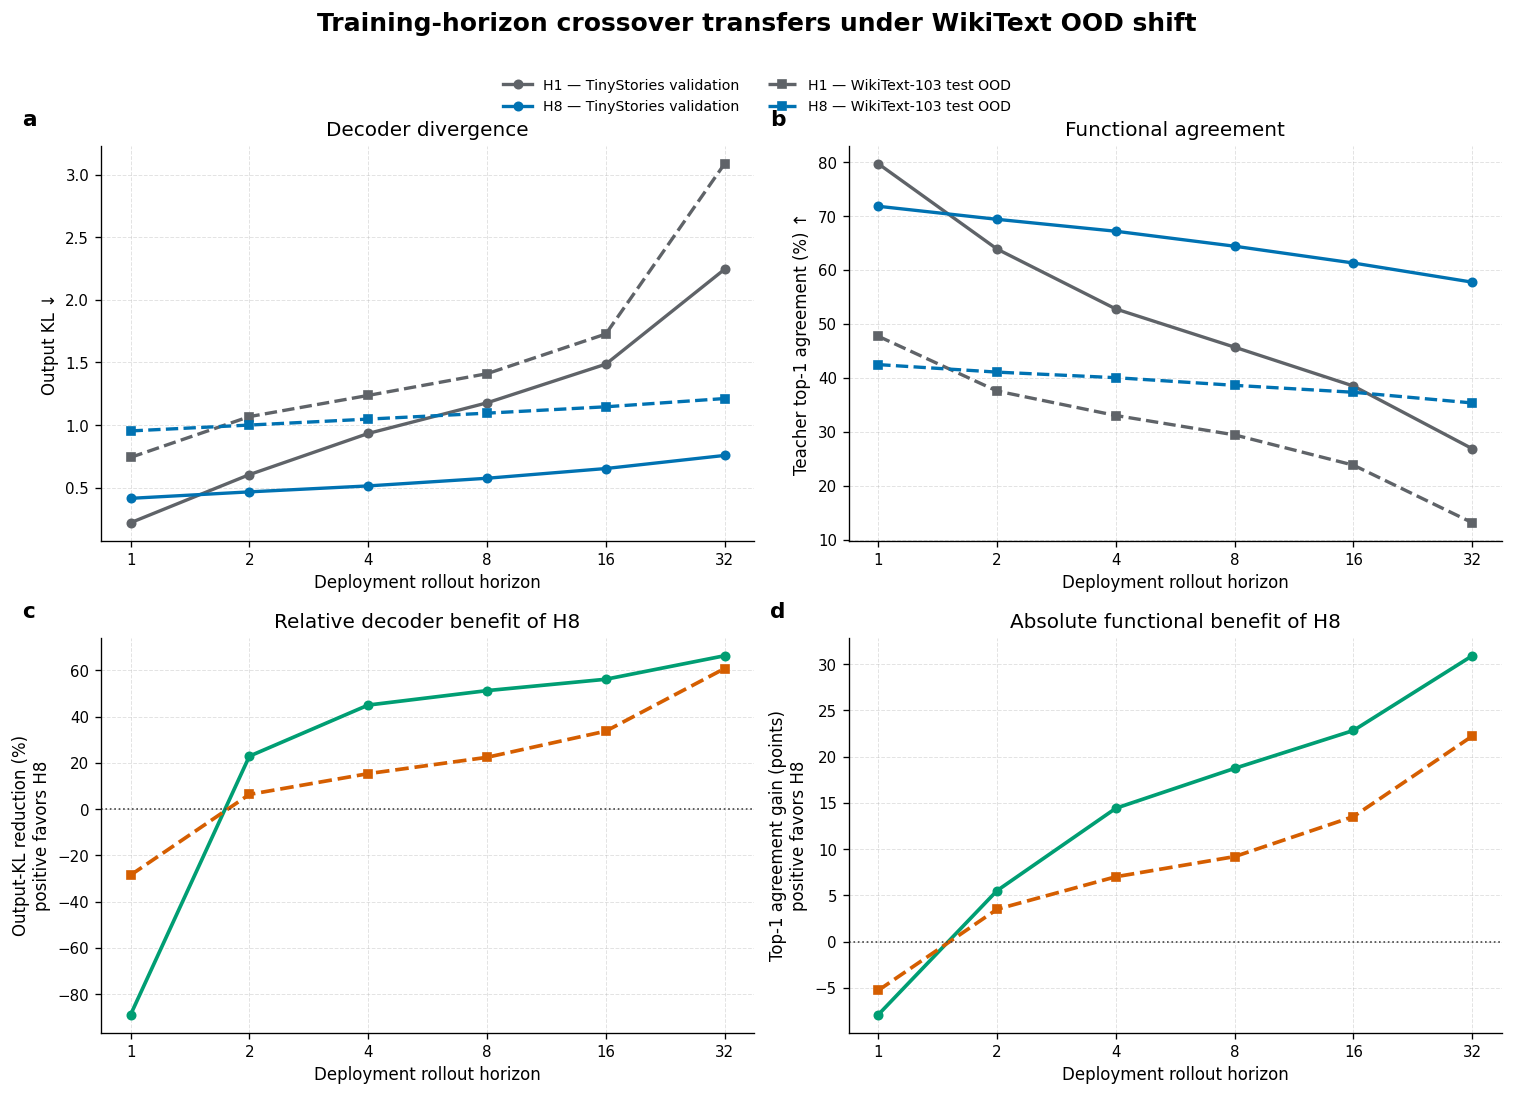

CROSS-DOMAIN FIGURE OUTPUT
PNG:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/tinystories_vs_wikitext_h1_h8_crossover_seed42.png
Size MB: 0.554

PDF:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/tinystories_vs_wikitext_h1_h8_crossover_seed42.pdf
Size MB: 0.033

Cell 26 cross-domain figure passed.


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

V3_RESULTS_FIGURE_DIR = (
    V3_ROOT
    / "results"
    / "figures"
)

V3_RESULTS_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CROSS_DOMAIN_FIGURE_PNG_PATH = (
    V3_RESULTS_FIGURE_DIR
    / (
        "tinystories_vs_wikitext_"
        "h1_h8_crossover_seed42.png"
    )
)

CROSS_DOMAIN_FIGURE_PDF_PATH = (
    V3_RESULTS_FIGURE_DIR
    / (
        "tinystories_vs_wikitext_"
        "h1_h8_crossover_seed42.pdf"
    )
)


# ------------------------------------------------------------------
# Build plotting tables
# ------------------------------------------------------------------

cross_domain_benefit_df = pd.concat(
    [
        tinystories_comparison_df.assign(
            domain="TinyStories validation"
        ),
        wikitext_comparison_df.assign(
            domain="WikiText-103 test OOD"
        ),
    ],
    ignore_index=True,
)

domain_styles = {
    "TinyStories validation": {
        "linestyle": "-",
        "marker": "o",
    },
    "WikiText-103 test OOD": {
        "linestyle": "--",
        "marker": "s",
    },
}

model_colors = {
    "H1": "#5F6368",
    "H8": "#0072B2",
}

benefit_colors = {
    "TinyStories validation": "#009E73",
    "WikiText-103 test OOD": "#D55E00",
}


# ------------------------------------------------------------------
# Plot configuration
# ------------------------------------------------------------------

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 8.5,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 8.2),
    constrained_layout=True,
)

(
    output_kl_axis,
    top1_axis,
    kl_benefit_axis,
    top1_benefit_axis,
) = axes.flatten()


# ------------------------------------------------------------------
# Panel A: absolute output KL
# ------------------------------------------------------------------

for domain_name in [
    "TinyStories validation",
    "WikiText-103 test OOD",
]:
    domain_df = (
        cross_domain_absolute_df[
            cross_domain_absolute_df[
                "domain"
            ]
            == domain_name
        ]
        .sort_values("horizon")
    )

    style = domain_styles[
        domain_name
    ]

    output_kl_axis.plot(
        domain_df["horizon"],
        domain_df["h1_output_kl"],
        color=model_colors["H1"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.0,
        markersize=5,
        label=f"H1 — {domain_name}",
    )

    output_kl_axis.plot(
        domain_df["horizon"],
        domain_df["h8_output_kl"],
        color=model_colors["H8"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.0,
        markersize=5,
        label=f"H8 — {domain_name}",
    )

output_kl_axis.set_title(
    "Decoder divergence"
)
output_kl_axis.set_ylabel(
    "Output KL ↓"
)


# ------------------------------------------------------------------
# Panel B: absolute top-1 agreement
# ------------------------------------------------------------------

for domain_name in [
    "TinyStories validation",
    "WikiText-103 test OOD",
]:
    domain_df = (
        cross_domain_absolute_df[
            cross_domain_absolute_df[
                "domain"
            ]
            == domain_name
        ]
        .sort_values("horizon")
    )

    style = domain_styles[
        domain_name
    ]

    top1_axis.plot(
        domain_df["horizon"],
        100.0
        * domain_df[
            "h1_top1_agreement"
        ],
        color=model_colors["H1"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.0,
        markersize=5,
        label=f"H1 — {domain_name}",
    )

    top1_axis.plot(
        domain_df["horizon"],
        100.0
        * domain_df[
            "h8_top1_agreement"
        ],
        color=model_colors["H8"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.0,
        markersize=5,
        label=f"H8 — {domain_name}",
    )

top1_axis.set_title(
    "Functional agreement"
)
top1_axis.set_ylabel(
    "Teacher top-1 agreement (%) ↑"
)


# ------------------------------------------------------------------
# Panel C: output-KL benefit
# ------------------------------------------------------------------

for domain_name in [
    "TinyStories validation",
    "WikiText-103 test OOD",
]:
    domain_df = (
        cross_domain_benefit_df[
            cross_domain_benefit_df[
                "domain"
            ]
            == domain_name
        ]
        .sort_values("horizon")
    )

    style = domain_styles[
        domain_name
    ]

    kl_benefit_axis.plot(
        domain_df["horizon"],
        domain_df[
            "output_kl_reduction_percent"
        ],
        color=benefit_colors[
            domain_name
        ],
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.2,
        markersize=5,
        label=domain_name,
    )

kl_benefit_axis.axhline(
    0,
    color="#444444",
    linewidth=1.0,
    linestyle=":",
)

kl_benefit_axis.set_title(
    "Relative decoder benefit of H8"
)
kl_benefit_axis.set_ylabel(
    "Output-KL reduction (%)\npositive favors H8"
)


# ------------------------------------------------------------------
# Panel D: top-1 benefit
# ------------------------------------------------------------------

for domain_name in [
    "TinyStories validation",
    "WikiText-103 test OOD",
]:
    domain_df = (
        cross_domain_benefit_df[
            cross_domain_benefit_df[
                "domain"
            ]
            == domain_name
        ]
        .sort_values("horizon")
    )

    style = domain_styles[
        domain_name
    ]

    top1_benefit_axis.plot(
        domain_df["horizon"],
        domain_df[
            "top1_agreement_gain_points"
        ],
        color=benefit_colors[
            domain_name
        ],
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.2,
        markersize=5,
        label=domain_name,
    )

top1_benefit_axis.axhline(
    0,
    color="#444444",
    linewidth=1.0,
    linestyle=":",
)

top1_benefit_axis.set_title(
    "Absolute functional benefit of H8"
)
top1_benefit_axis.set_ylabel(
    "Top-1 agreement gain (points)\npositive favors H8"
)


# ------------------------------------------------------------------
# Shared axis formatting
# ------------------------------------------------------------------

panel_labels = [
    "a",
    "b",
    "c",
    "d",
]

for panel_label, axis in zip(
    panel_labels,
    axes.flatten(),
):
    axis.set_xscale(
        "log",
        base=2,
    )

    axis.set_xticks(
        PROBE_HORIZONS
    )

    axis.set_xticklabels(
        [
            str(horizon)
            for horizon in PROBE_HORIZONS
        ]
    )

    axis.set_xlabel(
        "Deployment rollout horizon"
    )

    axis.grid(
        True,
        axis="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35,
    )

    axis.text(
        -0.12,
        1.04,
        panel_label,
        transform=axis.transAxes,
        fontsize=13,
        fontweight="bold",
        va="bottom",
    )


# One legend for absolute panels.
absolute_handles, absolute_labels = (
    output_kl_axis.get_legend_handles_labels()
)

figure.legend(
    absolute_handles,
    absolute_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
)

figure.suptitle(
    (
        "Training-horizon crossover transfers "
        "under WikiText OOD shift"
    ),
    fontsize=15,
    fontweight="bold",
    y=1.095,
)

figure.savefig(
    CROSS_DOMAIN_FIGURE_PNG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

figure.savefig(
    CROSS_DOMAIN_FIGURE_PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ------------------------------------------------------------------
# Verify saved figure
# ------------------------------------------------------------------

print("=" * 100)
print("CROSS-DOMAIN FIGURE OUTPUT")
print("=" * 100)

print("PNG:")
print(CROSS_DOMAIN_FIGURE_PNG_PATH)
print(
    "Size MB:",
    round(
        CROSS_DOMAIN_FIGURE_PNG_PATH
        .stat()
        .st_size
        / 1024**2,
        3,
    ),
)

print("\nPDF:")
print(CROSS_DOMAIN_FIGURE_PDF_PATH)
print(
    "Size MB:",
    round(
        CROSS_DOMAIN_FIGURE_PDF_PATH
        .stat()
        .st_size
        / 1024**2,
        3,
    ),
)

assert CROSS_DOMAIN_FIGURE_PNG_PATH.exists()
assert CROSS_DOMAIN_FIGURE_PDF_PATH.exists()
assert (
    CROSS_DOMAIN_FIGURE_PNG_PATH
    .stat()
    .st_size
    > 10_000
)
assert (
    CROSS_DOMAIN_FIGURE_PDF_PATH
    .stat()
    .st_size
    > 1_000
)

print(
    "\nCell 26 cross-domain "
    "figure passed."
)

In [26]:
import json
from pathlib import Path


def get_comparison_value(
    comparison_df,
    horizon,
    column,
):
    matched_rows = (
        comparison_df[
            comparison_df["horizon"]
            == horizon
        ]
    )

    assert len(matched_rows) == 1

    return float(
        matched_rows.iloc[0][column]
    )


def get_bootstrap_row(
    metric,
    horizon,
):
    matched_rows = (
        ood_cluster_bootstrap_df[
            (
                ood_cluster_bootstrap_df[
                    "metric"
                ]
                == metric
            )
            & (
                ood_cluster_bootstrap_df[
                    "horizon"
                ]
                == horizon
            )
        ]
    )

    assert len(matched_rows) == 1

    return matched_rows.iloc[0]


ood_kl_h1_bootstrap = get_bootstrap_row(
    "output_kl_improvement",
    1,
)

ood_kl_h2_bootstrap = get_bootstrap_row(
    "output_kl_improvement",
    2,
)

ood_kl_h8_bootstrap = get_bootstrap_row(
    "output_kl_improvement",
    8,
)

ood_kl_h32_bootstrap = get_bootstrap_row(
    "output_kl_improvement",
    32,
)

ood_top1_h1_bootstrap = get_bootstrap_row(
    "top1_agreement_improvement",
    1,
)

ood_top1_h2_bootstrap = get_bootstrap_row(
    "top1_agreement_improvement",
    2,
)

NOTEBOOK23_FINAL_SUMMARY_PATH = (
    V3_RESULTS_METADATA_DIR
    / "notebook23_final_summary_seed42.json"
)

notebook23_final_summary = {
    "notebook": (
        "23_ood_longform_evaluation.ipynb"
    ),
    "experiment_name": (
        "OOD evaluation on text sampled "
        "from long-form source documents"
    ),
    "research_question": (
        "Does the H1/H8 training-horizon "
        "crossover observed on TinyStories "
        "transfer to WikiText-103 test text?"
    ),
    "official_nextlat_commit": (
        OFFICIAL_COMMIT
    ),
    "training_seed": 42,
    "models": {
        "h1_checkpoint": str(
            H1_CHECKPOINT
        ),
        "h8_checkpoint": str(
            H8_CHECKPOINT
        ),
        "training_steps_each": 5000,
        "training_tokens_each": 81920000,
        "training_domain": "TinyStories",
        "training_horizons": [1, 8],
    },
    "ood_dataset": {
        "name": (
            "Salesforce/wikitext"
        ),
        "configuration": (
            "wikitext-103-raw-v1"
        ),
        "split": "test",
        "fingerprint": (
            wikitext_test._fingerprint
        ),
        "source_documents_detected": 62,
        "source_documents_used": 61,
        "chunks": 474,
        "chunk_length": 256,
        "chunks_per_document_cap": 8,
        "selection": (
            "evenly spaced non-overlapping "
            "chunks within each document"
        ),
        "tokenizer": (
            "official TinyStories tokenizer"
        ),
        "tokenizer_vocab_size": 1000,
        "audit_characters_per_token": float(
            characters_per_token
        ),
        "unknown_token_fraction": float(
            unknown_fraction
        ),
    },
    "evaluation": {
        "deployment_horizons": (
            PROBE_HORIZONS
        ),
        "teacher_token_conditioned": True,
        "long_context_evaluation": False,
        "description": (
            "The samples come from long-form "
            "documents, but model context length "
            "remains 256 tokens."
        ),
        "metrics": [
            "normalized_l2",
            "output_kl",
            "teacher_top1_agreement",
        ],
    },
    "main_ood_results": {
        "horizon_1": {
            "h8_output_kl_reduction_percent": (
                get_comparison_value(
                    wikitext_comparison_df,
                    1,
                    "output_kl_reduction_percent",
                )
            ),
            "h8_top1_gain_points": (
                get_comparison_value(
                    wikitext_comparison_df,
                    1,
                    "top1_agreement_gain_points",
                )
            ),
            "output_kl_improvement_ci": [
                float(
                    ood_kl_h1_bootstrap[
                        "ci_lower"
                    ]
                ),
                float(
                    ood_kl_h1_bootstrap[
                        "ci_upper"
                    ]
                ),
            ],
            "top1_improvement_ci": [
                float(
                    ood_top1_h1_bootstrap[
                        "ci_lower"
                    ]
                ),
                float(
                    ood_top1_h1_bootstrap[
                        "ci_upper"
                    ]
                ),
            ],
        },
        "horizon_2": {
            "h8_output_kl_reduction_percent": (
                get_comparison_value(
                    wikitext_comparison_df,
                    2,
                    "output_kl_reduction_percent",
                )
            ),
            "h8_top1_gain_points": (
                get_comparison_value(
                    wikitext_comparison_df,
                    2,
                    "top1_agreement_gain_points",
                )
            ),
            "output_kl_improvement_ci": [
                float(
                    ood_kl_h2_bootstrap[
                        "ci_lower"
                    ]
                ),
                float(
                    ood_kl_h2_bootstrap[
                        "ci_upper"
                    ]
                ),
            ],
            "top1_improvement_ci": [
                float(
                    ood_top1_h2_bootstrap[
                        "ci_lower"
                    ]
                ),
                float(
                    ood_top1_h2_bootstrap[
                        "ci_upper"
                    ]
                ),
            ],
        },
        "horizon_8": {
            "h8_output_kl_reduction_percent": (
                get_comparison_value(
                    wikitext_comparison_df,
                    8,
                    "output_kl_reduction_percent",
                )
            ),
            "h8_top1_gain_points": (
                get_comparison_value(
                    wikitext_comparison_df,
                    8,
                    "top1_agreement_gain_points",
                )
            ),
            "output_kl_improvement_ci": [
                float(
                    ood_kl_h8_bootstrap[
                        "ci_lower"
                    ]
                ),
                float(
                    ood_kl_h8_bootstrap[
                        "ci_upper"
                    ]
                ),
            ],
        },
        "horizon_32": {
            "h8_output_kl_reduction_percent": (
                get_comparison_value(
                    wikitext_comparison_df,
                    32,
                    "output_kl_reduction_percent",
                )
            ),
            "h8_top1_gain_points": (
                get_comparison_value(
                    wikitext_comparison_df,
                    32,
                    "top1_agreement_gain_points",
                )
            ),
            "output_kl_improvement_ci": [
                float(
                    ood_kl_h32_bootstrap[
                        "ci_lower"
                    ]
                ),
                float(
                    ood_kl_h32_bootstrap[
                        "ci_upper"
                    ]
                ),
            ],
        },
    },
    "cross_domain_results": {
        "tiny_stories_h8_output_kl_reduction_percent": {
            str(horizon): (
                get_comparison_value(
                    tinystories_comparison_df,
                    horizon,
                    "output_kl_reduction_percent",
                )
            )
            for horizon in PROBE_HORIZONS
        },
        "wikitext_h8_output_kl_reduction_percent": {
            str(horizon): (
                get_comparison_value(
                    wikitext_comparison_df,
                    horizon,
                    "output_kl_reduction_percent",
                )
            )
            for horizon in PROBE_HORIZONS
        },
        "crossover": (
            "H1 is functionally better at "
            "deployment horizon 1; H8 is "
            "functionally better from horizon "
            "2 through 32 in both domains."
        ),
        "ood_effect": (
            "The qualitative crossover transfers, "
            "but the medium-horizon H8 advantage "
            "is attenuated on WikiText."
        ),
    },
    "statistics": {
        "bootstrap_type": (
            "paired document-cluster bootstrap"
        ),
        "cluster_unit": "source document",
        "equal_document_weighting": True,
        "clusters": 61,
        "repetitions": 5000,
        "confidence_level": 0.95,
        "multiple_comparison_correction": None,
        "scope": (
            "Evaluation-document variation only; "
            "does not include training-seed "
            "uncertainty."
        ),
    },
    "scientific_conclusion": (
        "The training-horizon crossover transfers "
        "from TinyStories validation to WikiText-103 "
        "test text. H8 sacrifices one-step decoder "
        "fidelity but provides increasingly strong "
        "long-horizon functional stability. The "
        "medium-horizon advantage is smaller under "
        "OOD and tokenizer shift."
    ),
    "industrial_interpretation": (
        "Cross-domain rollout stability strengthens "
        "the case for testing H8 as a speculative "
        "drafter, but this notebook does not measure "
        "acceptance, KV-cache traffic, latency, "
        "throughput, or speedup."
    ),
    "limitations": [
        "single training seed",
        "one small model scale",
        "one OOD dataset",
        "TinyStories tokenizer causes strong "
        "WikiText subword fragmentation",
        "teacher-token-conditioned rollout",
        "256-token context only",
        "no autonomous acceptance measurement",
        "no hardware-performance claim",
    ],
    "decision": (
        "Proceed to matched H1/H8 acceptance-transfer "
        "evaluation before requesting larger compute."
    ),
    "artifacts": {
        "ood_protocol": str(
            OOD_PROTOCOL_JSON_PATH
        ),
        "ood_chunk_metadata": str(
            OOD_METADATA_CSV_PATH
        ),
        "full_results": str(
            OOD_FULL_RESULTS_PATH
        ),
        "full_comparison": str(
            OOD_FULL_COMPARISON_PATH
        ),
        "chunk_paired_statistics": str(
            OOD_CHUNK_PAIRED_PATH
        ),
        "document_paired_statistics": str(
            OOD_DOCUMENT_PAIRED_PATH
        ),
        "cluster_bootstrap": str(
            OOD_CLUSTER_BOOTSTRAP_PATH
        ),
        "cross_domain_absolute": str(
            CROSS_DOMAIN_ABSOLUTE_PATH
        ),
        "cross_domain_shift": str(
            CROSS_DOMAIN_SHIFT_PATH
        ),
        "figure_png": str(
            CROSS_DOMAIN_FIGURE_PNG_PATH
        ),
        "figure_pdf": str(
            CROSS_DOMAIN_FIGURE_PDF_PATH
        ),
    },
}

with open(
    NOTEBOOK23_FINAL_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        notebook23_final_summary,
        output_file,
        indent=2,
    )

print("=" * 120)
print("NOTEBOOK 23 FINAL SUMMARY")
print("=" * 120)

print(
    json.dumps(
        notebook23_final_summary,
        indent=2,
    )
)

print("\nSaved final summary:")
print(NOTEBOOK23_FINAL_SUMMARY_PATH)

assert NOTEBOOK23_FINAL_SUMMARY_PATH.exists()
assert (
    notebook23_final_summary[
        "ood_dataset"
    ]["source_documents_used"]
    == 61
)
assert (
    notebook23_final_summary[
        "statistics"
    ]["clusters"]
    == 61
)
assert (
    notebook23_final_summary[
        "evaluation"
    ]["long_context_evaluation"]
    is False
)

print(
    "\nNOTEBOOK 23 COMPLETE"
)

NOTEBOOK 23 FINAL SUMMARY
{
  "notebook": "23_ood_longform_evaluation.ipynb",
  "experiment_name": "OOD evaluation on text sampled from long-form source documents",
  "research_question": "Does the H1/H8 training-horizon crossover observed on TinyStories transfer to WikiText-103 test text?",
  "official_nextlat_commit": "3770be6009cea2b3c455a9ce7f2ca88b504bb955",
  "training_seed": 42,
  "models": {
    "h1_checkpoint": "/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_2.0028.pt",
    "h8_checkpoint": "/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42/NextLat_H8_5000Step_Seed42-seed42/ckpt_iter_5000_2.3431.pt",
    "training_steps_each": 5000,
    "training_tokens_each": 81920000,
    "training_domain": "TinyStories",
    "training_horizons": [
      1,
      8
    ]
  },
  "ood_dataset": {
    "name": "Salesforce/wikitext",
    "configuration": "wikitext